# CIVE70089 Design Project - Modelling Wastewater Treatment Plant N2O Emissions

## Part I -  Data Preprocessing and Exploration

This notebook provides the preprocessing pipeline applied to the raw N2O emissions dataset from the Avedøre wastewater treatment plant (WWTP) in Copenhagen, Denmark. This includes removing duplicates, handling negative values, aligning timestamps for a 2 minute sampling frequency and finally resampling the dataset to a 10 minute frequency.

The final 10 minute resampled dataframe is used for all subsequent data analysis, feature engineering and modelling of N2O emissions. 

Data source: https://data.mendeley.com/datasets/xmbxhscgpr/4

### Data Processing Pipeline 


The following data quality checks and preprocessing methods were applied to the raw data to ensure interpretability and consistency during feature engineering, exploratory data analysis and modelling: 

**1. Initial Quality Checks**

- Review data type, df shape and general descriptive statistics of the raw dataset✅
- Datetime: set as index and ensure chronological order ✅
- Remove duplicate values with equal timestamps ✅
- Drop tank 2 observations (full data only available for tank 1) ✅
- Clean variable names using defined naming conventions ✅

**2. Handle Negative Values**
- Handle negative values to ensure descriptive statistics / resampling is not distorted by negative outliers ✅

**3. Timestamp alignment** 
- Analyse timestamp distribution (sensor logging intervals)✅
- Align timestamps to odd minutes for 2 min sample frequency ✅ (SEE APPENDIX 1)
- Evaluate impact of aligning timestamps on empirical distribution ✅ (SEE APPENDIX 1)

**4. Resampling (10 min frequency)** 
- Define resampling function for numerical and categorical variables ✅
- Remove extreme outliers (only N2O) ✅
- Apply resampling for 10 min sample frequency ✅
- Evalute impact of resampling on empirical distribution ✅

Note: the resampling was completed on the non-aligned and aligned dataset to evaluate whether aligning timestamps before resampling the data makes a significant difference to data quality. This is specifically relevant when considering the application of machine learning models in real operational conditions, as the preprocessing pipeline should be as simple as possible without sacrificing the quality of the data to ensure computational efficiency.

For the final preprocessing pipeline, we decided to exclude timestamp alignment since it had no significant statistical impact on the quality / distribution of the 10 minute resampled data. This decision aligns with our overall objective of designing a data processing pipeline and models that are implementable, and therefore maintaining a data processing pipeline that avoids unneccessary and potentially computationally expensive steps. 

**5. Save the final dataset to .csv for feature engineering & modelling** ✅

**6. Appendices**

Appendix 1: Timestamp alignment
Code used to shift and aggregate all timestamps to odd minutes and analysis of the impact of shifting timestamps on the empirical distribution of the dataset. 

Appendix 2: Statistical comparison of resampling aligned and non-aligned datasets 

### 1. Initial Quality Checks

In [18]:
#Import relevant libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import gaussian_kde
from scipy.stats import ks_2samp, skew, kurtosis

import warnings
warnings.filterwarnings('ignore')

#Display settings 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)

#Plot settings
sns.set_theme(style="white", context="paper")

plt.rcParams['figure.dpi'] = 100  # Higher resolution figures
plt.rcParams['savefig.dpi'] = 300  # High quality when saving
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 13

In [4]:
#Define color mapping for key features for consistency 

base_color = '#1036DD'

color_map = {
    
    # Hydraulic / operational
    "inflow": "#001489",        
    "total_airflow": "#003E74", 
    "t1_airflow": "#2B8CBE",    

    # Nitrogen species
    "t1_n2o": "#D50032",      
    "t1_nh4": "#960058",        
    "t1_no3": "#653098", 

    # Process conditions
    "t1_do": "#00AEEF",     
     
    # Solids
    "t1_ss": "#6D6E71",      

    # Temperature
    "t1_temp": "#E87722",     

    # Phosphorus
    "t1_po4": "#00A651"        
}


In [3]:
#Upload csv file and check data types
#Note: file is too large to upload to GitHub, change the file path to your local directory to run the code
df = pd.read_csv("~/Desktop/Coding/cive70088/raw_data/aved_raw.csv") 
df.head() 

,time,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,BIOLOGY.LINE 3 TANK 1.O2 value,BIOLOGY.LINE 3 TANK 1.O2 quality,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1.SS value,BIOLOGY.LINE 3 TANK 1.SS quality,BIOLOGY.LINE 3 TANK 1.TEMPERATURE value,BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 2.O2 value,BIOLOGY.LINE 3 TANK 2.O2 quality,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 2.SS value,BIOLOGY.LINE 3 TANK 2.SS quality,BIOLOGY.LINE 3 TANK 2.TEMPERATURE value,BIOLOGY.LINE 3 TANK 2.TEMPERATURE quality,BIOLOGY.LINE 3.PHASECODE.SETPOINT value,BIOLOGY.LINE 3.PHASECODE.SETPOINT quality,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
0,2022-06-12 00:01:00+02:00,26829.375000,1.0,NaN,NaN,0.700231,0.0,1.66608,0.0,0.074907,0.0,0.058955,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.525374,1.0,NaN,NaN,NaN,NaN,1.384549,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.647483,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
1,2022-06-12 00:02:00+02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.238239,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.507085,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2,2022-06-12 00:03:00+02:00,29626.341797,1.0,NaN,NaN,0.697917,0.0,1.52727,0.0,0.074907,0.0,0.079933,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.536805,1.0,NaN,NaN,NaN,NaN,1.673177,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.594784,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
3,2022-06-12 00:04:00+02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.154271,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.432644,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
4,2022-06-12 00:05:00+02:00,28605.208984,1.0,NaN,NaN,0.656829,0.0,1.43633,0.0,0.056901,0.0,0.330223,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.509847,0.0,NaN,NaN,NaN,NaN,2.121311,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.631665,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


In [4]:
#Check shape of dataset 
shape = df.shape
print(f"The dataset contains {shape[0]} rows and {shape[1]} columns.")

The dataset contains 906815 rows and 49 columns.


In [5]:
#Check data types 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906815 entries, 0 to 906814
Data columns (total 49 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   time                                             906815 non-null  object 
 1   BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value          520588 non-null  float64
 2   BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality        520588 non-null  float64
 3   BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value          502835 non-null  float64
 4   BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality        502835 non-null  float64
 5   BIOLOGY.LINE 3 TANK 1.N2O value                  520546 non-null  float64
 6   BIOLOGY.LINE 3 TANK 1.N2O quality                520546 non-null  float64
 7   BIOLOGY.LINE 3 TANK 1.NH4 value                  520595 non-null  float64
 8   BIOLOGY.LINE 3 TANK 1.NH4 quality                520595 non-null  float64
 9   BIOLOGY.LINE 3 

In [6]:
#Check standard descriptive statistics 
df.describe().round(2) 

,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value,BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 1.N2O value,BIOLOGY.LINE 3 TANK 1.N2O quality,BIOLOGY.LINE 3 TANK 1.NH4 value,BIOLOGY.LINE 3 TANK 1.NH4 quality,BIOLOGY.LINE 3 TANK 1.NO3 value,BIOLOGY.LINE 3 TANK 1.NO3 quality,BIOLOGY.LINE 3 TANK 1.O2 value,BIOLOGY.LINE 3 TANK 1.O2 quality,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 1.SS value,BIOLOGY.LINE 3 TANK 1.SS quality,BIOLOGY.LINE 3 TANK 1.TEMPERATURE value,BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT value,BIOLOGY.LINE 3 TANK 2 VALVE 1.PCT quality,BIOLOGY.LINE 3 TANK 2.O2 value,BIOLOGY.LINE 3 TANK 2.O2 quality,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT value,BIOLOGY.LINE 3 TANK 2.O2.SETPOINT quality,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE value,BIOLOGY.LINE 3 TANK 2.PROCESSPHASE quality,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW value,BIOLOGY.LINE 3 TANK 2.Q.AIRFLOW quality,BIOLOGY.LINE 3 TANK 2.SS value,BIOLOGY.LINE 3 TANK 2.SS quality,BIOLOGY.LINE 3 TANK 2.TEMPERATURE value,BIOLOGY.LINE 3 TANK 2.TEMPERATURE quality,BIOLOGY.LINE 3.PHASECODE.SETPOINT value,BIOLOGY.LINE 3.PHASECODE.SETPOINT quality,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value,BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality,BIOLOGY.LINE 3 TANK 1.PO4 value,BIOLOGY.LINE 3 TANK 1.PO4 quality,INLET.Q value,INLET.Q quality,INLET.STATE.SWM INLET FLOW value,INLET.STATE.SWM INLET FLOW quality
count,520588.00,520588.00,502835.00,502835.0,520546.00,520546.00,520595.00,520595.00,520583.00,520583.00,520601.00,520601.00,526285.00,526285.0,519349.00,519349.0,470203.00,470203.00,520589.00,520589.00,506607.00,506607.0,473366.00,473366.0,520603.00,520603.00,526285.00,526285.0,519349.00,519349.0,470203.00,470203.00,520594.00,520594.00,506603.00,506603.0,526285.00,526285.0,526285.00,526285.0,526285.00,526285.0,520593.00,520593.00,454082.00,454082.00,526287.00,526287.0
mean,17132.97,0.08,44.47,0.0,0.10,0.13,2.31,0.11,2.78,0.05,0.62,0.13,0.63,0.0,1.50,0.0,2188.75,0.01,2.55,0.14,15.66,0.1,43.26,0.0,0.73,0.13,0.68,0.0,1.52,0.0,2158.95,0.01,2.63,0.14,15.56,0.1,1638.12,0.0,1.47,0.0,1.50,0.0,1.12,0.04,3080.39,0.02,0.14,0.0
std,7341.11,0.28,42.04,0.0,0.24,0.34,2.21,0.31,2.78,0.22,0.61,0.34,0.57,0.0,0.58,0.0,2133.80,0.11,0.86,0.34,3.38,0.3,41.03,0.0,0.75,0.34,0.62,0.0,0.58,0.0,2093.71,0.11,0.86,0.34,3.38,0.3,536.56,0.0,0.52,0.0,0.52,0.0,0.96,0.19,2327.10,0.14,0.34,0.0
min,0.00,0.00,0.00,0.0,-0.02,0.00,-0.00,0.00,-0.34,0.00,-0.04,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,6.49,0.0,0.00,0.0,-0.04,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,6.29,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.00,-5572.45,0.00,0.00,0.0
25%,11565.40,0.00,0.00,0.0,-0.01,0.00,0.95,0.00,1.18,0.00,0.15,0.00,0.00,0.0,1.00,0.0,0.00,0.00,2.14,0.00,12.62,0.0,0.00,0.0,0.18,0.00,0.00,0.0,1.00,0.0,0.00,0.00,2.04,0.00,12.53,0.0,1112.00,0.0,1.00,0.0,1.00,0.0,0.51,0.00,2095.49,0.00,0.00,0.0
50%,16800.33,0.00,40.70,0.0,0.01,0.00,1.87,0.00,2.18,0.00,0.33,0.00,1.00,0.0,2.00,0.0,2165.94,0.00,2.55,0.00,15.63,0.0,34.10,0.0,0.38,0.00,1.00,0.0,2.00,0.0,2132.10,0.00,2.74,0.00,15.54,0.0,1222.00,0.0,1.00,0.0,2.00,0.0,0.89,0.00,2303.82,0.00,0.00,0.0
75%,21809.08,0.00,89.20,0.0,0.11,0.00,3.03,0.00,3.73,0.00,0.99,0.00,1.04,0.0,2.00,0.0,4019.96,0.00,2.96,0.00,18.90,0.0,83.40,0.0,1.15,0.00,1.11,0.0,2.00,0.0,3913.27,0.00,3.18,0.00,18.82,0.0,2221.00,0.0,2.00,0.0,2.00,0.0,1.44,0.00,4328.12,0.00,0.00,0.0
max,43356.56,1.00,100.00,0.0,12.00,1.00,20.01,1.00,52.66,1.00,10.85,1.00,2.50,0.0,2.00,0.0,12973.05,1.00,35.09,1.00,27.13,1.0,100.00,0.0,10.85,1.00,2.50,0.0,2.00,0.0,12703.26,1.00,50.14,1.00,27.13,1.0,2222.00,0.0,2.00,0.0,2.00,0.0,16.56,1.00,17192.57

#### Set datetime index 

In [7]:
#Set time as index (datetime format) 

# Parse time safely
df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True)

# Check unparsable timestamps
nat_count = df["time"].isna().sum()
print(f"Number of unparsable dates in 'time' column: {nat_count}")

# Drop rows with invalid timestamps
df = df.dropna(subset=["time"]).copy()

# --- Set time as index and sort ---
df = df.set_index("time").sort_index()

Number of unparsable dates in 'time' column: 0


In [8]:
print("Time range:", df.index.min(), "to", df.index.max())
print("Shape after parsing: ",df.shape)

Time range: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00
Shape after parsing:  (906815, 48)


#### Drop duplicate values & tank 2 observations

In [9]:
#Check for exact duplicate rows
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

# Drop exact duplicates
df = df[~duplicate_rows].copy()

# Check for duplicate timestamps (same time index)
time_duplicates = df.index.duplicated()
print(f"Number of duplicate timestamps: {time_duplicates.sum()}")

# Drop duplicated timestamps (keep first occurrence)
df = df[~df.index.duplicated(keep='first')].copy()

print(f"Shape after removing duplicates: {df.shape}")


Number of duplicate rows: 108349
Number of duplicate timestamps: 0
Shape after removing duplicates: (798466, 48)


In [10]:
# Drop tank 2 observations 
tank2_cols = [col for col in df.columns if 'TANK 2' in col]

df_t1 = df.copy()

# Drop TANK 2 columns
df_t1.drop(columns=tank2_cols, inplace=True)

print(f"Shape after dropping TANK 2 columns: {df_t1.shape}")
print() 
print(f"Columns in df_t1:")
print(df_t1.columns)

Shape after dropping TANK 2 columns: (798466, 34)

Columns in df_t1:
Index(['BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value', 'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality', 'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value', 'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality',
       'BIOLOGY.LINE 3 TANK 1.N2O value', 'BIOLOGY.LINE 3 TANK 1.N2O quality', 'BIOLOGY.LINE 3 TANK 1.NH4 value', 'BIOLOGY.LINE 3 TANK 1.NH4 quality', 'BIOLOGY.LINE 3 TANK 1.NO3 value',
       'BIOLOGY.LINE 3 TANK 1.NO3 quality', 'BIOLOGY.LINE 3 TANK 1.O2 value', 'BIOLOGY.LINE 3 TANK 1.O2 quality', 'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value',
       'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality', 'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value', 'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality', 'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value',
       'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality', 'BIOLOGY.LINE 3 TANK 1.SS value', 'BIOLOGY.LINE 3 TANK 1.SS quality', 'BIOLOGY.LINE 3 TANK 1.TEMPERATURE value',
       'BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality', 'BIOLOG

#### Clean variable names 

**Variable naming convention**

- Prefix 't1': tank 1 observations 
- Suffix '_q': data quality indicator (binary variable)

In [12]:
#Clean variable names for easier access and readability

#Mapping of old column names to new names   
column_names = {
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value': 'total_airflow',
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality': 'total_airflow_q',

    'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value': 't1_valve_pct',
    'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality': 't1_valve_pct_q',

    'BIOLOGY.LINE 3 TANK 1.N2O value': 't1_n2o',
    'BIOLOGY.LINE 3 TANK 1.N2O quality': 't1_n2o_q',

    'BIOLOGY.LINE 3 TANK 1.NH4 value': 't1_nh4',
    'BIOLOGY.LINE 3 TANK 1.NH4 quality': 't1_nh4_q',

    'BIOLOGY.LINE 3 TANK 1.NO3 value': 't1_no3',
    'BIOLOGY.LINE 3 TANK 1.NO3 quality': 't1_no3_q',

    'BIOLOGY.LINE 3 TANK 1.O2 value': 't1_do', #dissolved oxygen concentration in tank 1
    'BIOLOGY.LINE 3 TANK 1.O2 quality': 't1_do_q',

    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value': 't1_do_sp', #controller target for DO concentration in tank 1
    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality': 't1_do_sp_q',

    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value': 't1_phase', # 0 - anaerobic, 1 - anoxic, 2 - aerobic
    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality': 't1_phase_q',

    'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value': 't1_airflow',
    'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality': 't1_airflow_q',

    'BIOLOGY.LINE 3 TANK 1.SS value': 't1_ss', #tank 1 - suspended solids concentration - biomass proxy
    'BIOLOGY.LINE 3 TANK 1.SS quality': 't1_ss_q',

    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE value': 't1_temp', 
    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality': 't1_temp_q',

    'BIOLOGY.LINE 3.PHASECODE.SETPOINT value': 'phasecode', #controller target for process phase (0 - anaerobic, 1 - anoxic, 2 - aerobic)
    'BIOLOGY.LINE 3.PHASECODE.SETPOINT quality': 'phasecode_q',

    'BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK value': 'inlet_tank',
    'BIOLOGY.LINE 3.PROCESSPHASE.INLET TANK quality': 'inlet_tank_q',

    'BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK value': 'outlet_tank',
    'BIOLOGY.LINE 3.PROCESSPHASE.OUTLET TANK quality': 'outlet_tank_q',

    'BIOLOGY.LINE 3 TANK 1.PO4 value': 't1_po4', #tank 1 - PO4 concentration
    'BIOLOGY.LINE 3 TANK 1.PO4 quality': 't1_po4_q',

    'INLET.Q value': 'inflow', #total influent flow 
    'INLET.Q quality': 'inflow_q',

    'INLET.STATE.SWM INLET FLOW value': 'storm_mode', #binary variable indicating storm conditions 
    'INLET.STATE.SWM INLET FLOW quality': 'storm_mode_q'
}

#Ensure all keys exist 
missing_keys = [k for k in column_names.keys() if k not in df_t1.columns]

if missing_keys:
    print("These columns were not found and will not be renamed:")
    print(missing_keys)
else: 
    print("All columns found.")

#Rename columns in dataframe 

df_t1 = df_t1.rename(columns=column_names).copy() 


These columns were not found and will not be renamed:
['BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value', 'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW quality', 'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT value', 'BIOLOGY.LINE 3 TANK 1 VALVE 1.PCT quality', 'BIOLOGY.LINE 3 TANK 1.N2O value', 'BIOLOGY.LINE 3 TANK 1.N2O quality', 'BIOLOGY.LINE 3 TANK 1.NH4 value', 'BIOLOGY.LINE 3 TANK 1.NH4 quality', 'BIOLOGY.LINE 3 TANK 1.NO3 value', 'BIOLOGY.LINE 3 TANK 1.NO3 quality', 'BIOLOGY.LINE 3 TANK 1.O2 value', 'BIOLOGY.LINE 3 TANK 1.O2 quality', 'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value', 'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT quality', 'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value', 'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE quality', 'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value', 'BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW quality', 'BIOLOGY.LINE 3 TANK 1.SS value', 'BIOLOGY.LINE 3 TANK 1.SS quality', 'BIOLOGY.LINE 3 TANK 1.TEMPERATURE value', 'BIOLOGY.LINE 3 TANK 1.TEMPERATURE quality', 'BIOLOGY.LINE 3.PHASECODE.SETPOINT value', 'BIOLOGY.LINE 3.PHAS

### 3. Timestamp alignment - analysis of sensor logging intervals

##### Inspect sensor readings - odd vs even minutes

In [13]:
#Inspect distribution of timestamps across minutes 
min_counts = df_t1.index.minute.value_counts().sort_index()
print("Minute distribution of timestamps:")
print(min_counts)

Minute distribution of timestamps:
time
0     14562
1     12263
2     14540
3     12107
4     14501
5     12126
6     14552
7     12151
8     14521
9     12068
10    14552
11    12079
12    14520
13    12128
14    14519
15    12024
16    14498
17    12048
18    14517
19    12034
20    14525
21    12114
22    14548
23    12070
24    14553
25    12075
26    14559
27    12004
28    14542
29    12043
30    14589
31    12050
32    14579
33    12028
34    14549
35    12058
36    14564
37    12047
38    14531
39    12062
40    14550
41    12192
42    14556
43    12072
44    14561
45    12086
46    14530
47    12051
48    14528
49    12063
50    14541
51    12063
52    14555
53    12060
54    14526
55    12040
56    14525
57    12040
58    14527
59    12000
Name: count, dtype: int64


The minute distribution shows a consistent pattern with approximately ~14500 observations at even minutes and ~12,000 at odd minutes. This indicates that the dataset is drifting due to a systematic issue in sensor readings. 

In [14]:
#Compare even and odd minute sensor reading count distribution 
time_min = df_t1.index.minute
even_count = (time_min % 2 == 0).sum()
odd_count = (time_min % 2 != 0).sum()

print("Even-minute timestamps:", even_count)
print("Odd-minute timestamps:", odd_count)
print("Even %:", round(even_count / len(df_t1) * 100, 2))
print("Odd %:", round(odd_count / len(df_t1) * 100, 2))


Even-minute timestamps: 436220
Odd-minute timestamps: 362246
Even %: 54.63
Odd %: 45.37


Sensor readings are relatively evenly distributed across even and odd minutes across the dataset. 

In [17]:
#Check time how much time difference there is between consecutive timestamps
time_diffs = df_t1.index.to_series().diff().dropna()

print(time_diffs.value_counts().head(10))
print() 
print("Most common time difference between consecutive timestamps:")
print(time_diffs.mode())

time
0 days 00:01:00    555196
0 days 00:02:00    243134
0 days 00:03:00        39
0 days 00:04:00        29
0 days 00:05:00        14
0 days 00:06:00         7
0 days 00:08:00         4
0 days 00:20:00         4
0 days 01:20:00         4
0 days 00:37:00         3
Name: count, dtype: int64

Most common time difference between consecutive timestamps:
0   0 days 00:01:00
Name: time, dtype: timedelta64[ns]


Most of the sensor readings occur within a 1 minute or 2 minute sampling interval, with a few irregular longer gaps in consecutive readings (the longest three consecutive gaps between timestamps is 37 minutes). The longer gaps in timestamps could indicate issues related to sensor outages or more extreme operational conditions. 

In [15]:
#Check the percentage of observations occurring on drifted minutes (odd minutes) for each sensor variable
features_num = ["t1_n2o", "t1_do", "t1_airflow", "t1_nh4", "t1_no3", "t1_temp", "t1_ss", "t1_po4"]

results = {}

drift_mask = df_t1.index.minute % 2 != 0

for col in features_num:
    non_na = df_t1[col].notna()
    
    total_obs = non_na.sum()
    drifted_obs = (non_na & drift_mask).sum()
    
    drift_pct = (drifted_obs / total_obs) * 100 if total_obs > 0 else 0
    
    results[col] = drift_pct

drift_df = pd.Series(results).sort_values(ascending=False)

print("Percentage of observations occurring on drifted minutes:")
print(drift_df.round(2))

Percentage of observations occurring on drifted minutes:
t1_no3        54.77
t1_temp       52.94
t1_do         51.51
t1_po4        45.10
t1_ss         43.67
t1_nh4        42.50
t1_airflow    39.52
t1_n2o        39.15
dtype: float64


### 2. Handling negative values 

##### Analyse distribution of negative outliers 

In [39]:
# Review distribution of negative values

#Define df for numeric features only 
cols_num = ['inflow', 'total_airflow', 't1_airflow', 't1_n2o', 't1_nh4',
     't1_no3', 't1_do', 't1_ss', 't1_temp', 't1_po4']

numeric_features = df_t1[cols_num].copy() 

numeric_features.describe()


,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,451934.000000,520534.000000,470173.000000,505759.000000,520548.000000,519651.000000,510296.000000,520583.000000,505210.000000,518090.000000
mean,3084.441937,17134.540514,2188.871401,0.106368,2.307489,2.777480,0.619086,2.552897,15.662830,1.124565
std,2330.036653,7339.694910,2133.811869,0.243830,2.209582,2.778070,0.611928,0.862613,3.381554,0.964287
min,-5572.451660,0.000000,0.000000,-0.023727,-0.004505,-0.338735,-0.035807,0.000000,6.488715,0.000000
25%,2095.486084,11566.583008,0.000000,-0.009259,0.947521,1.179137,0.155527,2.137651,12.617549,0.511719
50%,2303.819336,16801.083984,2166.187302,0.012731,1.866830,2.175297,0.335286,2.550490,15.640372,0.890906
75%,4331.597656,21809.250000,4020.047030,0.116319,3.030480,3.727712,0.995732,2.964671,18.907335,1.442171
max,17192.570312,43356.562500,12973.047180,12.000000,20.007799,52.658241,10.850695,35.092827,27.126736,16.555120


In [40]:
#Compute the number and percentage of negative values for each variable 
negative_counts = numeric_features.lt(0).sum()
negative_frac = numeric_features.lt(0).mean()*100

print(negative_counts.sort_values(ascending=False))
print()
print(negative_frac.sort_values(ascending=False))

t1_n2o           164406
t1_do              3161
inflow              198
t1_nh4               50
t1_no3                1
total_airflow         0
t1_airflow            0
t1_ss                 0
t1_temp               0
t1_po4                0
dtype: int64

t1_n2o           20.590232
t1_do             0.395884
inflow            0.024798
t1_nh4            0.006262
t1_no3            0.000125
total_airflow     0.000000
t1_airflow        0.000000
t1_ss             0.000000
t1_temp           0.000000
t1_po4            0.000000
dtype: float64


In [41]:
#Check distribution of negative values 
numeric_features[numeric_features < 0].describe()

,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,198.000000,0.0,0.0,164406.000000,50.000000,1.000000,3161.000000,0.0,0.0,0.0
mean,-833.994650,NaN,NaN,-0.017442,-0.001307,-0.338735,-0.014316,NaN,NaN,NaN
std,1002.812838,NaN,NaN,0.008185,0.001488,NaN,0.007816,NaN,NaN,NaN
min,-5572.451660,NaN,NaN,-0.023727,-0.004505,-0.338735,-0.035807,NaN,NaN,NaN
25%,-1042.098358,NaN,NaN,-0.023727,-0.002748,-0.338735,-0.020616,NaN,NaN,NaN
50%,-358.183044,NaN,NaN,-0.023148,-0.000551,-0.338735,-0.013383,NaN,NaN,NaN
75%,-172.281803,NaN,NaN,-0.010995,-0.000112,-0.338735,-0.006510,NaN,NaN,NaN
max,-12.849655,NaN,NaN,-0.000579,-0.000112,-0.338735,-0.001808,NaN,NaN,NaN


**Note:** For all features except for n2o, the percentage of negative values represent < 1% of the total observations. For n2o, the percentage of negative values is significantly higher at ~ 20.6%.  In terms of the distribution of the negative values, for all concentration based variables, the negative values are distributed near zero. For inflow, the negative outliers are much larger in magnitude, with the minimum at -5572.5 m3. 

#### Distribution of N2O Negative Sensor Readings

Since negative N2O readings represent a significant proportion of the total observations for N2O (~20%), we completed additional analysis of the distribution of negative N2O readings to understand their magnitude and whether they occur during specific time periods. 

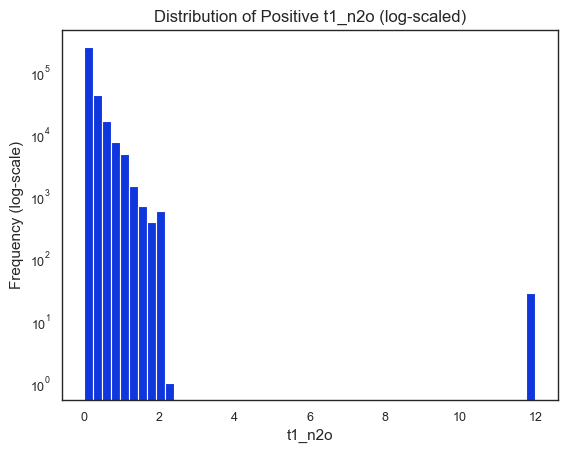

In [ ]:
#Plot distribution of positive values for t1_n2o (log scale frequency)
plt.figure()
plt.hist(numeric_features['t1_n2o'][numeric_features['t1_n2o'] > 0], bins=50, color="#1036DD")
plt.yscale('log')
plt.xlabel("t1_n2o")
plt.ylabel("Frequency (log-scale)")
plt.title("Distribution of Positive t1_n2o (log-scaled)")
plt.show()

In [43]:
#Plot distribution of negative values for t1_n2o after removing extreme outlier 
#Remove extreme values
df_n2o = df_t1['t1_n2o'].copy() 
df_n2o.loc[df_n2o > 5] = np.nan
print("Remaining extreme values:", (df_n2o > 5).sum())
print("New max value:", df_n2o.max())

Remaining extreme values: 0
New max value: 2.1701388359069824


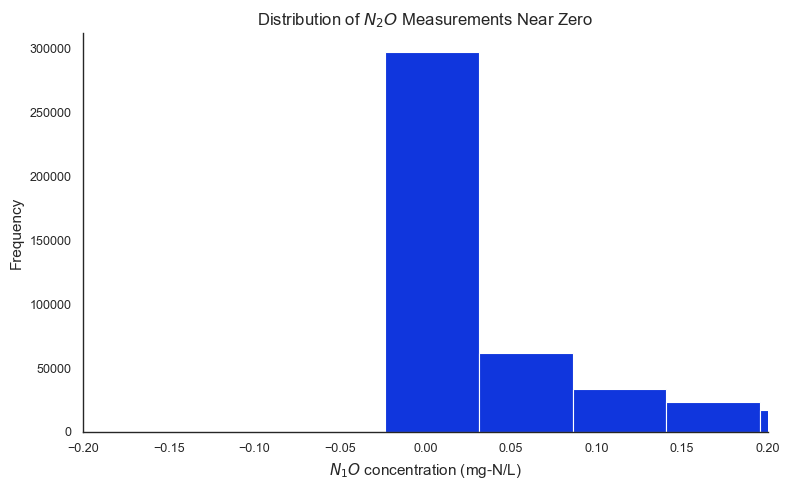

In [ ]:
#Plot distribution of t1_n2o near zero 

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(
    df_n2o,
    bins=40,
    color="#1036DD",
    alpha=1,
    edgecolor="white",
    ax=ax
)

ax.set_xlim(-0.2, 0.2)

ax.set_xlabel(r"$N_1O$ concentration (mg-N/L)")
ax.set_ylabel("Frequency")
ax.set_title(r"Distribution of $N_2O$ Measurements Near Zero")

sns.despine()

plt.tight_layout()
plt.show()

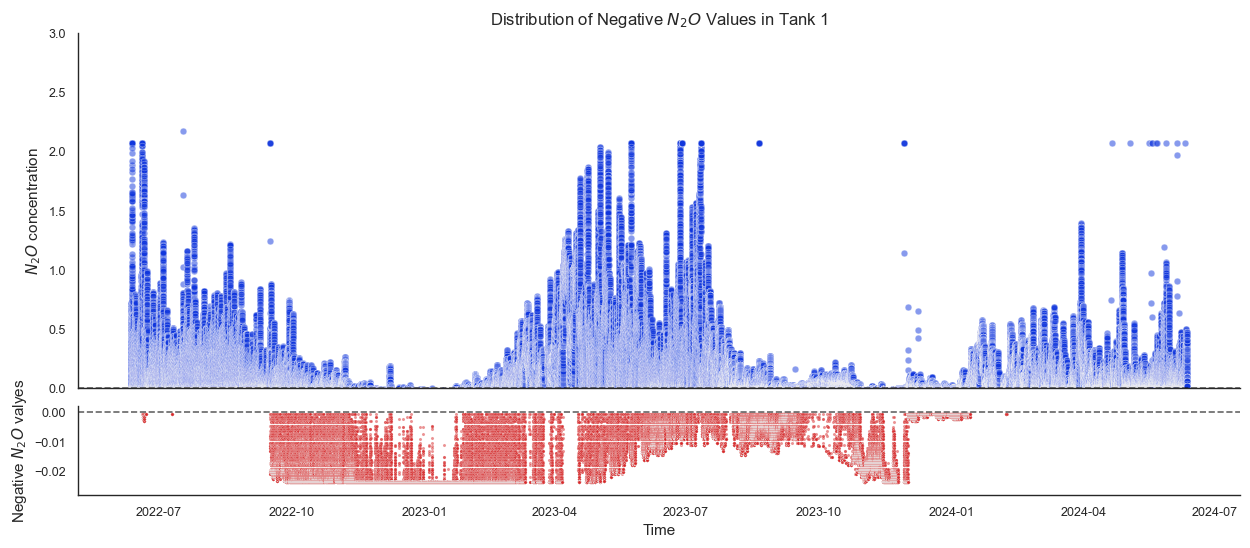

In [45]:
#Plot distribution of negative t1_n2o values across the time series 

#Identify negative values
neg = df_t1[df_t1["t1_n2o"] < 0]

# Create figure with two plots
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(15,6),
    sharex=True,
    gridspec_kw={"height_ratios":[4,1]}
)

# Top panel: N2O timeseries scatter plot 
sns.scatterplot(
    x=df_t1.index,
    y=df_t1["t1_n2o"],
    color="#1036DD",
    alpha=0.5,
    ax=ax1
)

ax1.axhline(0, linestyle="--", color="black", alpha=0.6)

ax1.set_ylabel(r"$N_2O$ concentration")
ax1.set_ylim(0,3)


ax1.set_title(r"Distribution of Negative $N_2O$ Values in Tank 1")

# Bottom panel: negative N2O readings
sns.scatterplot(
    x=neg.index,
    y=neg["t1_n2o"],
    color="#D62728",
    s=5,
    alpha=0.5,
    ax=ax2
)

ax2.axhline(0, linestyle="--", color="black", alpha=0.6)

ax2.set_ylabel(r"Negative $N_2O$ valyes")
ax2.set_xlabel("Time")
ax2.set_ylim(-0.028,0.002)

sns.despine()
plt.subplots_adjust(hspace=0.08)

plt.show()

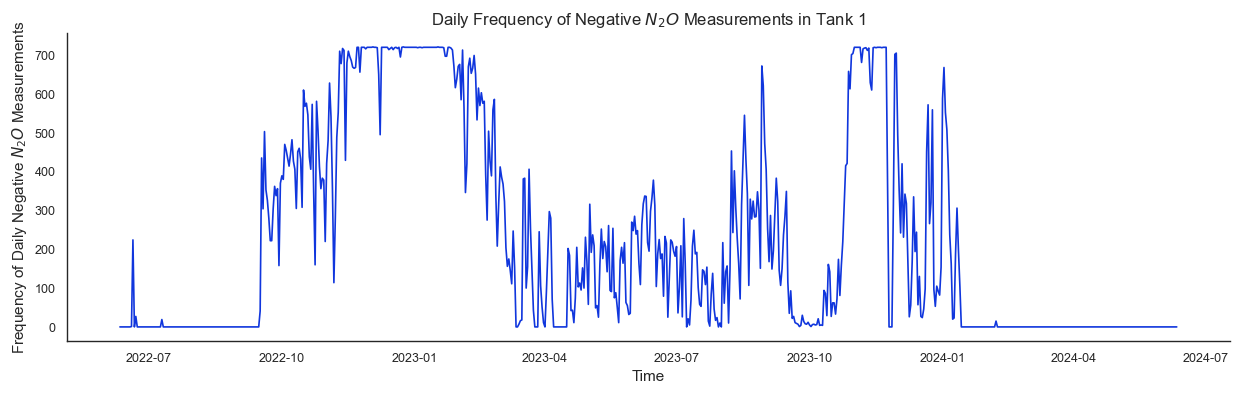

In [46]:
#Plot count of negative N2O readings 

#Calculate negative value counts per day (resample - sum)
neg_counts = (df_t1["t1_n2o"] < 0).resample("D").sum()

fig, ax = plt.subplots(figsize=(15,4))

#Plot daily negative reading counts across time series 
sns.lineplot(
    data=neg_counts,
    color='#1036DD',
    ax=ax
)

ax.set_xlabel("Time")
ax.set_ylabel(r"Frequency of Daily Negative $N_2O$ Measurements")
ax.set_title(r"Daily Frequency of Negative $N_2O$ Measurements in Tank 1")

sns.despine()
plt.show()

#### Distribution of negative inflow values

The proportion of negative inflow values is small, representing only ~0.02% of the total inflow measurements. However, since the magnitudes of the negative measurements are significantly larger, applying a linear shift to all observations is not an appropriate method. 

To assess whether we should use interpolation to estimate these values, we analysed the distribution of the negative outliers to identify whether they occur in a continuous seuqence or in isolated incidents.

In [50]:
# Review distribution of negative inflow values 

#total number of negative inflow values
total_negative_inflow = (numeric_features['inflow'] < 0).sum()
print(f"Total number of negative inflow values: {total_negative_inflow}")

# Distribution of negative inflow values
negative_inflow_distribution = numeric_features[numeric_features['inflow'] < 0]['inflow'].describe()
print("Distribution of negative inflow values:")
print(negative_inflow_distribution)

Total number of negative inflow values: 198
Distribution of negative inflow values:
count     198.000000
mean     -833.994650
std      1002.812838
min     -5572.451660
25%     -1042.098358
50%      -358.183044
75%      -172.281803
max       -12.849655
Name: inflow, dtype: float64


In [51]:
# Check if negative values occur in isolated instances or in consecutive sequences

#Define mask for negative inflow values 
neg_mask = numeric_features["inflow"] < 0

# Identify consecutive sequences of negative inflow values
negative_sequences = neg_mask.groupby(neg_mask.ne(neg_mask.shift()).cumsum()).sum()

# Filter out instances of negative inflow 
negative_sequences = negative_sequences[negative_sequences > 0]

negative_sequences.describe()

count    189.000000
mean       1.047619
std        0.213524
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: inflow, dtype: float64

**Interpretation:** the count of isolated sequences of negative inflow values (1 or more consecutive negative values) is 189 which indicates that most of the negative observations are isolated instances (total number of negative inflow values is 198), likely caused by sensor issues, etc. 

The longest consecutive sequence of negative values is 2. Therefore we will use interpolation to estimate the missing inflow values using the length of the interval between the observations. 

#### Apply transformations to negative outliers

#### Linear transformation of biological parameters

For the biological parameters, 't1_n2o','t1_nh4', 't1_no3', 't1_do', we applied a linear shift since the negative readings are centered around zero.

In [ ]:
#Apply linear shift to negative concentration values 
cols_linear = ['t1_n2o','t1_nh4', 't1_no3', 't1_do']
min_values = df_t1[cols_linear].min() 
shifts = (-min_values).clip(lower=0)

#Apply constant shift to each column
df_t1[cols_linear] = df_t1[cols_linear].add(shifts)

In [49]:
#Verify minima 
df_t1[cols_linear].min()

t1_n2o    0.0
t1_nh4    0.0
t1_no3    0.0
t1_do     0.0
dtype: float64

##### Interpolation - Inflow

In [52]:
#For inflow, interpolate values since negative outliers are isolated cases 

#Ensure that df is in chronological order
df_t1 = df_t1.sort_index()

#Identify negative inflow values and set to NaN
neg_mask_inflow = df_t1['inflow'] < 0 
df_t1.loc[neg_mask_inflow,'inflow'] = np.nan

#interpolate using length of interval between observations
df_t1['inflow'] = df_t1['inflow'].interpolate(method='time',limit_area='inside')

In [54]:
#Check for any remaining negative values 
remaining_negatives = (df_t1['inflow'] < 0).sum()
print(f"Number of remaining negative inflow values after interpolation: {remaining_negatives}")

#Check NaN values
nan_counts = df_t1['inflow'].isna().sum()
print(f"Number of NaN values in inflow after interpolation: {nan_counts}")

Number of remaining negative inflow values after interpolation: 0
Number of NaN values in inflow after interpolation: 112043


##### Check NaN values for Inflow 

In [55]:
#select inflow column and check for leading and trailing NaNs
inflow_s = df_t1["inflow"]
print("Leading NaNs:", inflow_s.isna().cumprod().sum())
print("Trailing NaNs:", inflow_s.isna()[::-1].cumprod().sum())

Leading NaNs: 112043
Trailing NaNs: 0


In [56]:
#Identify consecutive NaN gaps in inflow and compute their lengths
inflow_na = inflow_s.isna()
gap_id = inflow_na.ne(inflow_na.shift()).cumsum()
gap_lengths = inflow_na.groupby(gap_id).sum()
missing_gaps = gap_lengths[gap_lengths > 0]

missing_gaps.describe()


count         1.0
mean     112043.0
std           NaN
min      112043.0
25%      112043.0
50%      112043.0
75%      112043.0
max      112043.0
Name: inflow, dtype: float64

In [57]:
#Check when NaN values occur
first_valid = inflow_s.first_valid_index()

print("NaNs occur from", inflow_s.index.min(), "to", inflow_s.loc[:first_valid].index[inflow_s.loc[:first_valid].isna()].max())
print("Any NaNs after first valid?", inflow_s.loc[first_valid:].isna().any())


NaNs occur from 2022-06-11 22:01:00+00:00 to 2022-09-12 10:13:00+00:00
Any NaNs after first valid? False


**Note on NaN values for inflow:**

NaN values for inflow occur in one continuous missing block of 112,043 rows from 2022-06-11 22:01:00+00:00 to 2022-09-12 10:13:00+00:00 in the beginning of the dataset. This confirms that the values were not introduced by interpolation, and will be handled at a later stage.

### 4. Resampling (10-min frequency)



Finally, we resample the dataset to 10 minute sampling intervals, applying the following resampling methods: 

- Numerical features: resampled using the mean value.
- Categorical / discrete states: resampled using mode to identify the dominant pgase during the 10 minute window. 
- Storm mode (watchdog signal): maximum for resampling to preserve signal of wet-weather conidtions within the 10 minute interval.
- Quality indicators ('_q'): mode to select most frequent data quality signal during the interval. 

#### Timeseries & boxplot overview (before resampling)

##### Global Timeseries - Key Features

In [58]:
#Check descriptive statistics after treating negative values 
df_t1[cols_num].describe().round(2) 

,inflow,total_airflow,t1_airflow,t1_n2o,t1_nh4,t1_no3,t1_do,t1_ss,t1_temp,t1_po4
count,686423.00,520534.00,470173.00,505759.00,520548.00,519651.00,510296.00,520583.00,505210.00,518090.00
mean,3100.25,17134.54,2188.87,0.13,2.31,3.12,0.65,2.55,15.66,1.12
std,2327.95,7339.69,2133.81,0.24,2.21,2.78,0.61,0.86,3.38,0.96
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.49,0.00
25%,2095.49,11566.58,0.00,0.01,0.95,1.52,0.19,2.14,12.62,0.51
50%,2310.76,16801.08,2166.19,0.04,1.87,2.51,0.37,2.55,15.64,0.89
75%,4322.92,21809.25,4020.05,0.14,3.03,4.07,1.03,2.96,18.91,1.44
max,17192.57,43356.56,12973.05,12.02,20.01,53.00,10.89,35.09,27.13,16.56


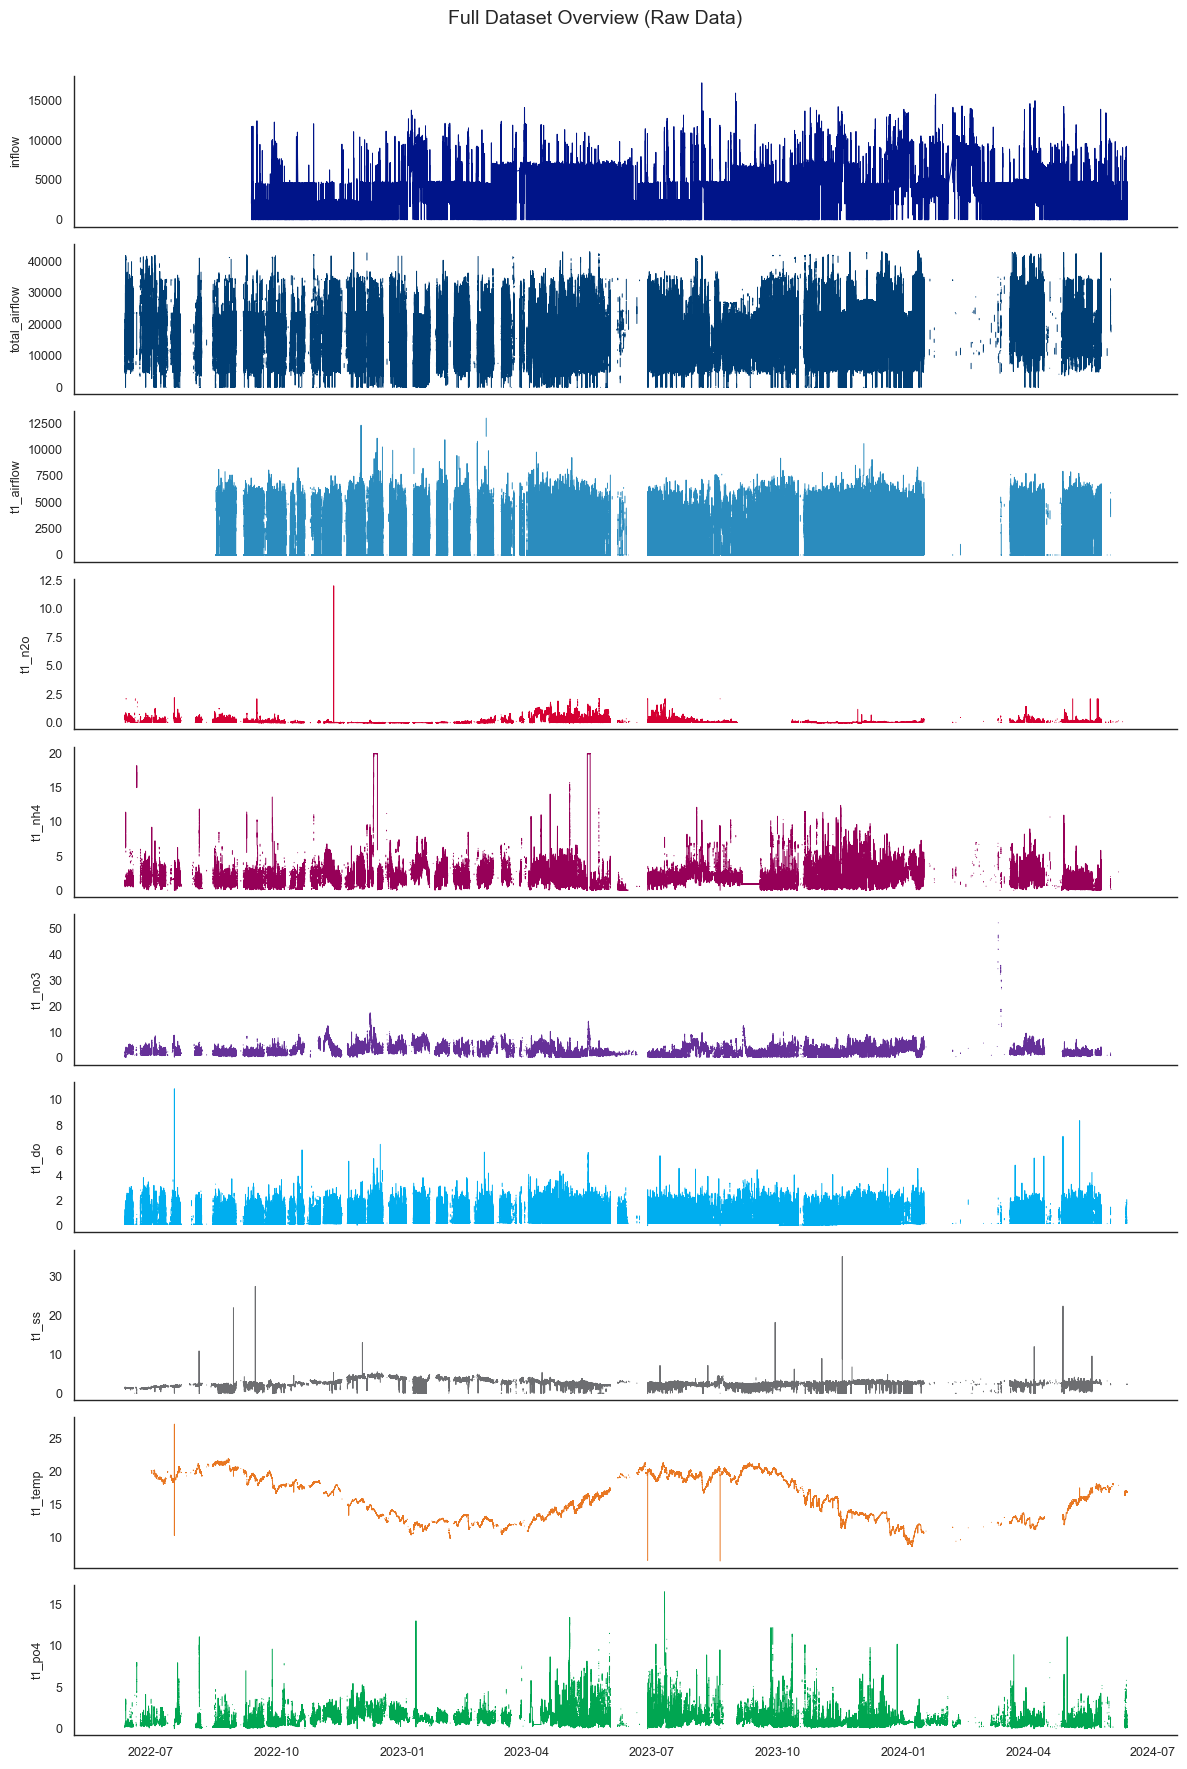

In [59]:
#Global overview of numeric variables after treating negative values
plot_df = df_t1[cols_num].copy() 

fig, axes = plt.subplots(
    nrows=len(cols_num),
    ncols=1,
    figsize=(12,18),
    sharex=True
)

for i, col in enumerate(cols_num):

    axes[i].plot(
        df_t1.index,
        df_t1[col],
        linewidth=0.7,
        color=color_map.get(col, "#333333")
    )

    axes[i].set_ylabel(col, fontsize=9)

plt.suptitle("Full Dataset Overview (Raw Data)", fontsize=14)

sns.despine()
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

#### Boxplots - Identify Outliers 

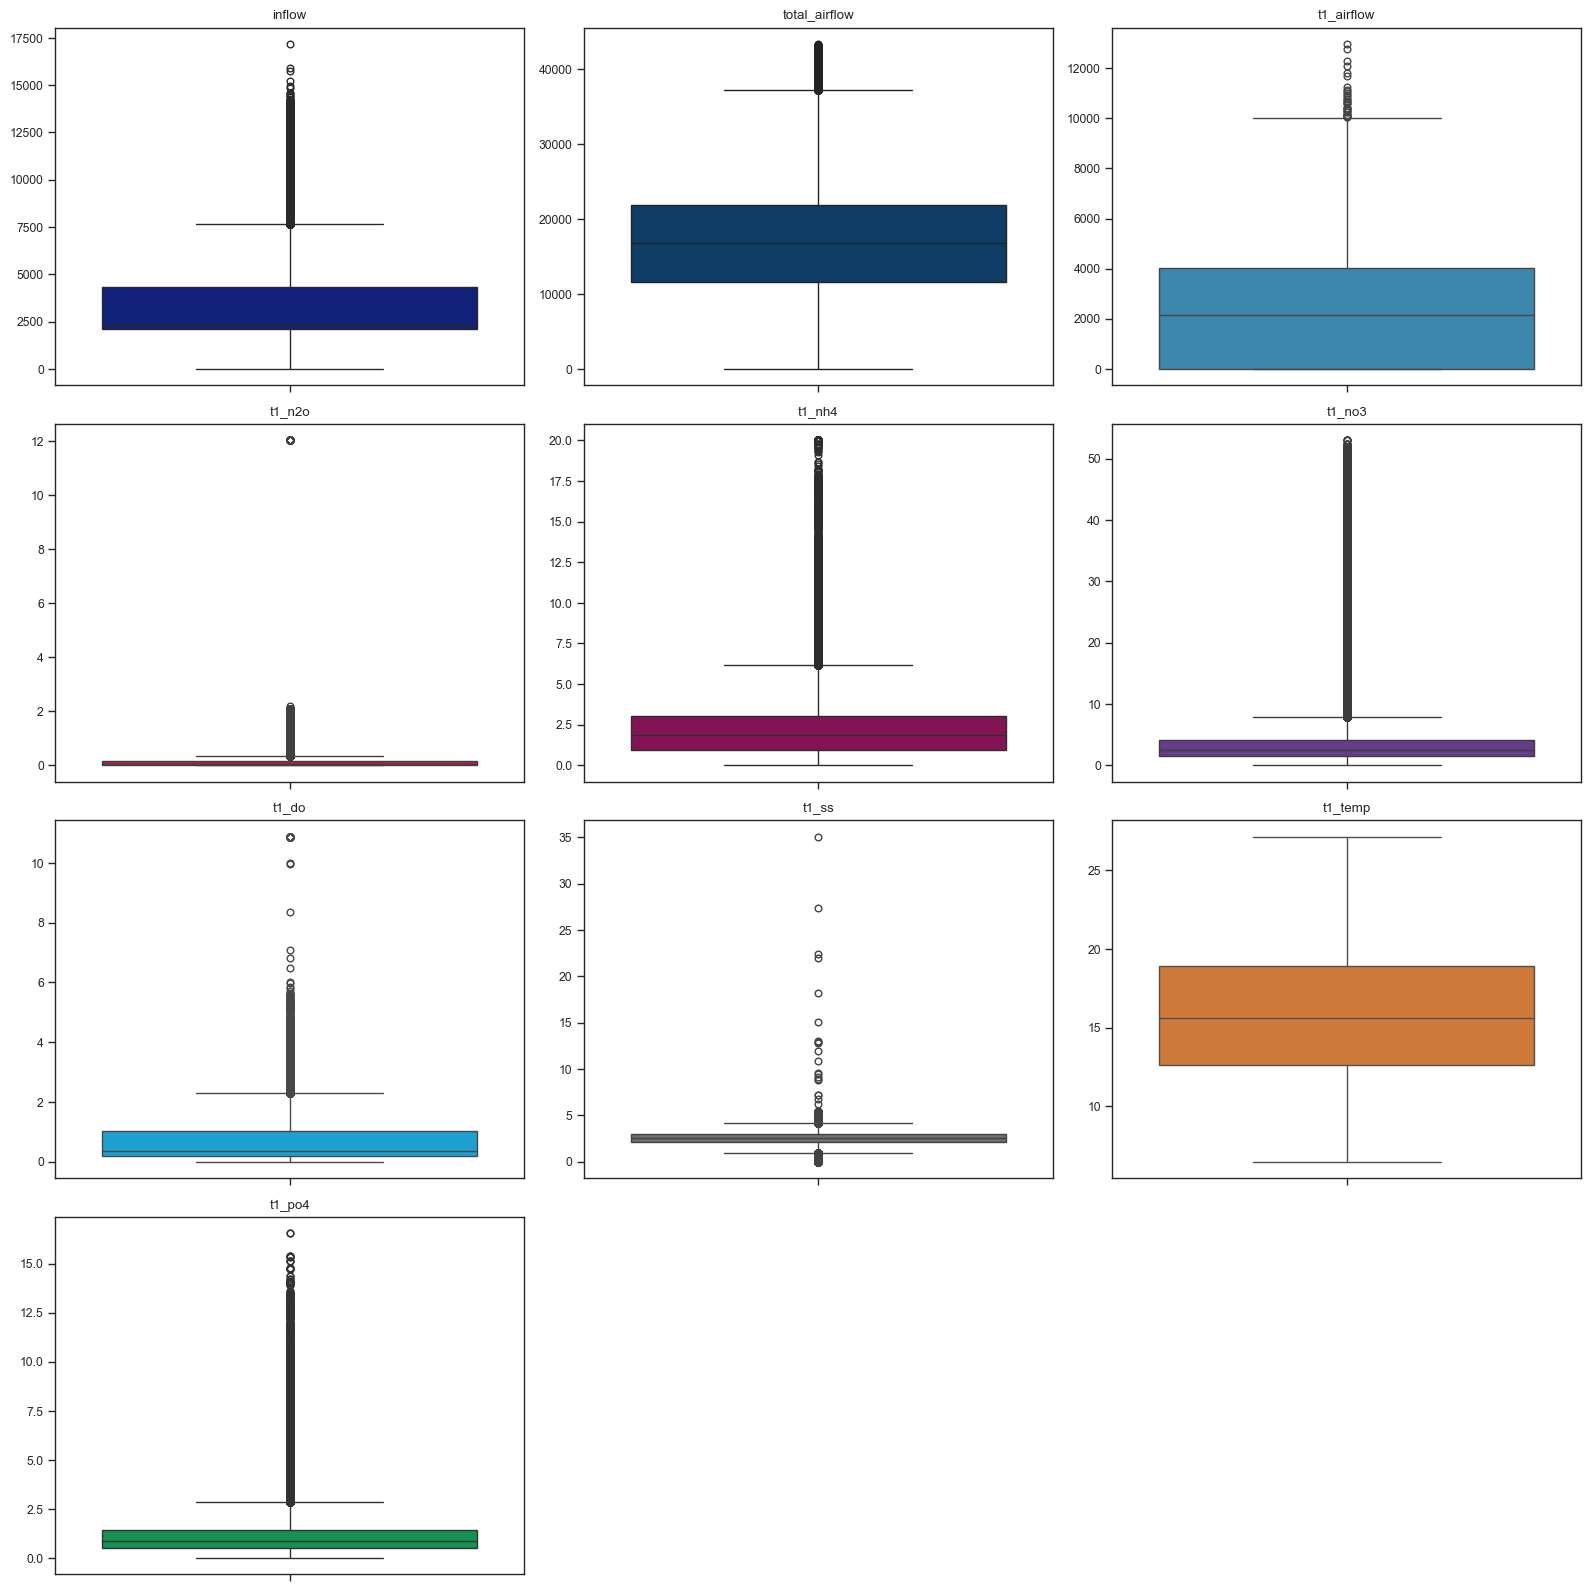

In [149]:
#Boxplots to check for outliers after treating negative values

n_cols = 3
n_rows = math.ceil(len(cols_num) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.boxplot(
    y=df_t1[col],
    ax=axes[i],
    color=color_map[col]
    )
    axes[i].set_title(col)
    axes[i].set_ylabel("")
    
# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Remove Extreme Outliers

In order to preserve real peaks in key variables, notably N2O emissions, across the sampling period, we decided to only remove one set of extreme values for N2O emissions, which likely occurred due to a sensor outage / flatlining. Ideally, we choose to not remove significant proportions of the data before modelling as different seasons and operational phases show significant variations in N2O emissions. 

This set of outliers with value 12.02 can be seen in the above boxplot. Since the values are significantly larger in magnitude than the rest of the readings and occur in a single cluster (27 continuous readings with the same value), we assume that the reading is not related to real operational variability. 

In [121]:
#Remove single N2O value 
max_idx = df_t1["t1_n2o"].idxmax()
print(f"Max t1_n2o value: {df_t1.loc[max_idx, 't1_n2o']} at timestamp {max_idx}")

#remove single outlier value 
df_t1.loc[max_idx, "t1_n2o"] = np.nan

Max t1_n2o value: 12.023726852610707 at timestamp 2022-11-11 08:36:00+00:00


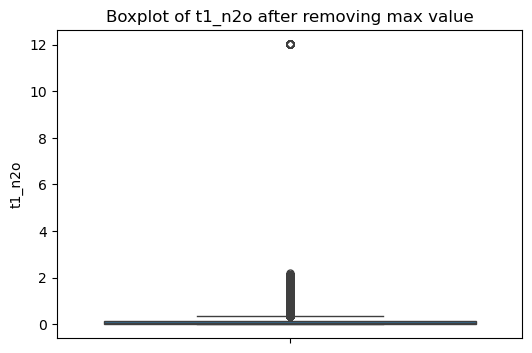

In [122]:
#plot boxplot for t1_n2o to check for outliers after removing max value
plt.figure(figsize=(6,4))
sns.boxplot(y=df_t1['t1_n2o'], flierprops=dict(marker='o', markersize=5))
plt.title("Boxplot of t1_n2o after removing max value")
plt.ylabel("t1_n2o")
plt.show()

##### Check count and distribution of outlier values

In [ ]:
extreme_count = (df_t1["t1_n2o"] > 5).sum()
print("Number of extreme N2O values (>5):", extreme_count)

extreme_pct = (df_t1["t1_n2o"] > 5).mean() * 100
print(f"Percentage of extreme N2O values: {extreme_pct:.4f}%")

Number of extreme N2O values (>5): 27
Percentage of extreme N2O values: 0.0034%


In [125]:
df_t1[df_t1["t1_n2o"] > 5]["t1_n2o"].describe().round(2)

count    27.00
mean     12.02
std       0.00
min      12.02
25%      12.02
50%      12.02
75%      12.02
max      12.02
Name: t1_n2o, dtype: float64

In [ ]:
df_t1[df_t1["t1_n2o"] > 5].indexj

DatetimeIndex(['2022-11-11 08:38:00+00:00', '2022-11-11 08:40:00+00:00',
               '2022-11-11 08:42:00+00:00', '2022-11-11 08:44:00+00:00',
               '2022-11-11 08:46:00+00:00', '2022-11-11 08:48:00+00:00',
               '2022-11-11 08:50:00+00:00', '2022-11-11 08:52:00+00:00',
               '2022-11-11 08:54:00+00:00', '2022-11-11 08:56:00+00:00',
               '2022-11-11 08:58:00+00:00', '2022-11-11 09:00:00+00:00',
               '2022-11-11 09:02:00+00:00', '2022-11-11 09:04:00+00:00',
               '2022-11-11 09:06:00+00:00', '2022-11-11 09:38:00+00:00',
               '2022-11-11 09:40:00+00:00', '2022-11-11 09:42:00+00:00',
               '2022-11-11 09:44:00+00:00', '2022-11-11 09:46:00+00:00',
               '2022-11-11 09:48:00+00:00', '2022-11-11 09:50:00+00:00',
               '2022-11-11 09:52:00+00:00', '2022-11-11 09:54:00+00:00',
               '2022-11-11 09:56:00+00:00', '2022-11-11 09:58:00+00:00',
               '2022-11-11 10:00:00+00:00'],
      

The extreme values occur in a continuous time block. 

In [60]:
df_t1.loc[df_t1["t1_n2o"] > 5, "t1_n2o"] = np.nan
print("Remaining extreme values:", (df_t1["t1_n2o"] > 5).sum())
print("New max value:", df_t1["t1_n2o"].max())

Remaining extreme values: 0
New max value: 2.1938656885176897


#### Define Resampling Function

In [66]:
#Resample original dataframe df_t1 

#sort to ensure chronological order
df_t1 = df_t1.sort_index()

#Define column groups for resampling

continuous_cols = [
    'total_airflow', 't1_valve_pct', 't1_n2o', 't1_nh4', 't1_no3', 't1_do', 't1_do_sp', 't1_airflow', 't1_ss',
    't1_temp', 't1_po4', 'inflow'
]

phase_cols = ['t1_phase', 'phasecode', 'inlet_tank', 'outlet_tank']

binary_cols = ['storm_mode']

quality_cols = [col for col in df_t1.columns if col.endswith('_q')]

In [67]:
#Define resampling function

def resample_mixed(df, freq):

    df = df.sort_index()

    # Continuous → mean
    df_cont = df[continuous_cols].resample(freq).mean()

    # Phase/state → mode
    df_phase = (
        df[phase_cols]
        .resample(freq)
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

    # Binary → max
    df_binary = df[binary_cols].resample(freq).max()

    # Quality flags → mode (safe default)
    df_quality = (
        df[quality_cols]
        .resample(freq)
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

    # Combine
    df_resampled = pd.concat(
        [df_cont, df_phase, df_binary, df_quality],
        axis=1
    )

    return df_resampled

In [68]:
#Resample to 10 min frequency 
df_10T = resample_mixed(df_t1, "10T")

In [69]:
#Check shapes of resampled dataframes
print(f"Original df shape: {df_t1.shape}")
print(f"10 min resampled df shape: {df_10T.shape}") 

Original df shape: (798466, 34)
10 min resampled df shape: (105264, 34)


In [ ]:
#Save to CSV 
df_10T.to_csv("../../data/df_10T.csv", index=True)

In [138]:
#Save df_t1 with treated negative values and removed outliers to csv for future use
df_t1.to_csv("../../data/df_t1_cleaned.csv", index=True)

##### Check timeseries data after resampling

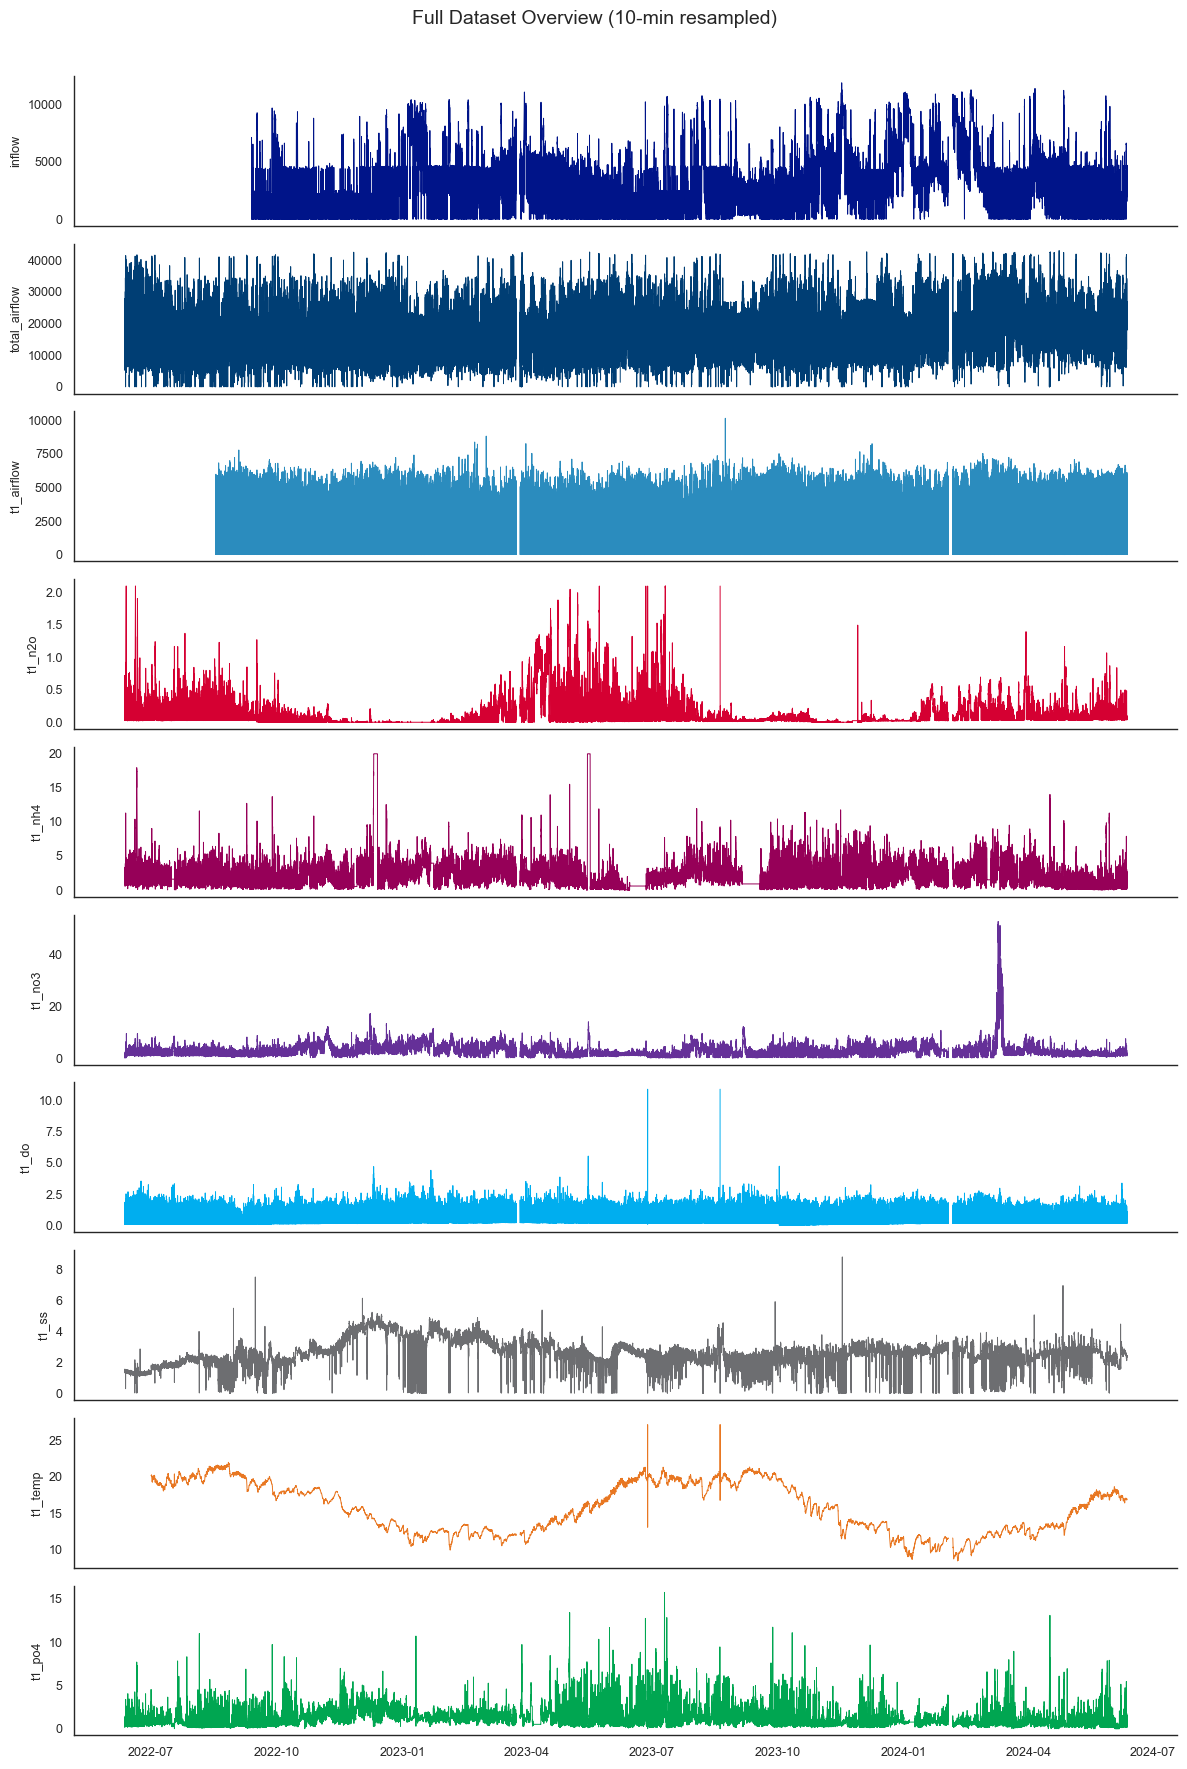

In [70]:
#Global overview of numeric variables after treating negative values
plot_df = df_10T[cols_num].copy() 

fig, axes = plt.subplots(
    nrows=len(cols_num),
    ncols=1,
    figsize=(12,18),
    sharex=True
)

for i, col in enumerate(cols_num):

    axes[i].plot(
        df_10T.index,
        df_10T[col],
        linewidth=0.7,
        color=color_map.get(col, "#333333")
    )

    axes[i].set_ylabel(col, fontsize=9)

plt.suptitle("Full Dataset Overview (10-min resampled)", fontsize=14)

sns.despine()
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

### Appendices

#### Appendix 1: Timestamp alignment (optional step, not implemented in final preprocessing pipeline)

The data points should be recorded with a 2 minute sample frequency. However, sensor readings can often be delayed by factors such as sensor drift, physical fouling or poor calibration, leading to irregular data logging.

In the following section we assess the extent to which sensor readings are logged in irregular intervals across individual variables and align all timestamps to odd minutes to transform the data to 2 minute sample frequency before resampling. 

In [28]:
#Define variables used to select rows with missing values in key variables
vars_align = ['t1_n2o', 't1_do', 't1_airflow', 't1_nh4', 't1_no3', 't1_temp']

In [ ]:
#Create duplicate dataframe for aligning timestamps 
df_aligned = df_t1.copy() 

#Ensure chronological order 
df_aligned = df_aligned.sort_index()

print(f"Original number of rows:", {len(df_t1)})

Original number of rows: {798466}


In [20]:
#Store original timezone 
orig_tz = df_aligned.index.tz
df_aligned.index = df_aligned.index.tz_localize(None)

#Floor to the nearest minute (round down)
df_aligned.index = df_aligned.index.floor('1T')

#Create copy of timestamp array 
new_times = df_aligned.index.values.copy()

#Save minute portion
minutes = df_aligned.index.minute

#Shift even minutes back by 1 minute
even_mask = (minutes % 2 == 0)
new_times[even_mask] -= np.timedelta64(1, 'm')

#Replace df_aligned index with adjusted timestamps
df_aligned.index = pd.DatetimeIndex(new_times)

#Remove duplicates by grouping rows by timestamp
#Only the values in the first rows are kept - can drop data?
df_aligned = df_aligned.groupby(level=0).first()

#Filter out even minutes
df_aligned = df_aligned[df_aligned.index.minute % 2 != 0]

#Reapply original timezone 
if orig_tz is not None:
    df_aligned.index = df_aligned.index.tz_localize(orig_tz)

#Sort chronologically 
df_aligned = df_aligned.sort_index()

#Check shape of new df and verify that even timestamps have been removed
print(f"--- Completed ---")
print(f"Original number of rows: {len(df_t1)}")
print(f"Aligned total rows: {len(df_aligned)}")
print(f"Even timestamp exists: {(df_aligned.index.minute % 2 == 0).any()}")

--- Completed ---
Original number of rows: 798466
Aligned total rows: 520868
Even timestamp exists: False


In [21]:
#Check data integrity by comparing the number of NaN and zero values in original and aligned dataframes for value columns

def check_data_integrity(original_df, processed_df):
    
    stats = []
    
    numeric_cols = original_df.select_dtypes(include='number').columns
    
    for col in numeric_cols:
        
        orig_series = original_df[col]
        processed_series = processed_df[col] if col in processed_df.columns else None
        
        orig_count = len(orig_series)
        processed_count = len(processed_series) if processed_series is not None else np.nan

        orig_nan = orig_series.isna().sum()
        processed_nan = processed_series.isna().sum() if processed_series is not None else np.nan

        stats.append({
            'Feature': col,
            
            # ---- NaN counts ----
            'Original_NaN': orig_nan,
            'Processed_NaN': processed_nan,
            
            # ---- % NaN ----
            'Original_%_NaN': (orig_nan / orig_count) * 100,
            'Processed_%_NaN': (processed_nan / processed_count) * 100 if processed_series is not None else np.nan,
            
            # ---- Zero counts ----
            'Original_Zeros': (orig_series == 0).sum(),
            'Processed_Zeros': (processed_series == 0).sum() if processed_series is not None else np.nan,
            
            # ---- Mean ----
            'Original_Mean': orig_series.mean(),
            'Processed_Mean': processed_series.mean() if processed_series is not None else np.nan,
            'Mean_Diff': (processed_series.mean() - orig_series.mean()) if processed_series is not None else np.nan,
            
            # ---- Standard Deviation ----
            'Original_Std': orig_series.std(),
            'Processed_Std': processed_series.std() if processed_series is not None else np.nan,
            'Std_Diff': (processed_series.std() - orig_series.std()) if processed_series is not None else np.nan,
            
            # ---- Sum ----
            'Original_Sum': orig_series.sum(),
            'Processed_Sum': processed_series.sum() if processed_series is not None else np.nan,
            'Sum_Diff': (processed_series.sum() - orig_series.sum()) if processed_series is not None else np.nan,
            'Sum_%_Diff': ((processed_series.sum() - orig_series.sum()) 
               / orig_series.sum()) * 100
               if processed_series is not None else np.nan,
            
            # ---- Min / Max ----
            'Original_Min': orig_series.min(),
            'Processed_Min': processed_series.min() if processed_series is not None else np.nan,
            'Original_Max': orig_series.max(),
            'Processed_Max': processed_series.max() if processed_series is not None else np.nan
        })
        
    return pd.DataFrame(stats)

In [29]:
#Check general statistics for original and aligned dataframes
comparison_aligned = check_data_integrity(df_t1[vars_align], df_aligned[vars_align])
comparison_aligned.head().round(3) 

,Feature,Original_NaN,Processed_NaN,Original_%_NaN,Processed_%_NaN,Original_Zeros,Processed_Zeros,Original_Mean,Processed_Mean,Mean_Diff,Original_Std,Processed_Std,Std_Diff,Original_Sum,Processed_Sum,Sum_Diff,Sum_%_Diff,Original_Min,Processed_Min,Original_Max,Processed_Max
0,t1_n2o,292707,17087,36.659,3.280,7718,7711,0.106,0.106,-0.000,0.244,0.243,-0.001,5.379644e+04,5.338313e+04,-413.307,-0.768,-0.024,-0.024,12.000,12.000
1,t1_do,288170,14298,36.090,2.745,22,22,0.619,0.619,-0.000,0.612,0.612,-0.000,3.159170e+05,3.134482e+05,-2468.754,-0.781,-0.036,-0.035,10.851,10.851
2,t1_airflow,328293,50841,41.115,9.761,193767,193707,2188.871,2188.793,-0.078,2133.812,2133.760,-0.052,1.029148e+09,1.028792e+09,-356325.924,-0.035,0.000,0.000,12973.047,12973.047
3,t1_nh4,277918,2740,34.806,0.526,99,99,2.307,2.310,0.002,2.210,2.208,-0.002,1.201159e+06,1.196736e+06,-4422.521,-0.368,-0.005,-0.005,20.008,20.008
4,t1_no3,278815,4041,34.919,0.776,7201,7175,2.777,2.782,0.004,2.778,2.781,0.003,1.443320e+06,1.437641e+06,-5679.339,-0.393,-0.339,-0.339,52.658,52.658


**Notes on results:** 

- Significant decrease in % of NaN values (% of values in a given column that are NaN)
- Zero values: approximately the same, no significant change 
- Mean: no significant change in mean values 
- Standard deviation: no significant change
- Sum: processed data set has lower sum than the original, which indicates some values were removed due to aggregation (only first duplicate kept) - howedver, the changes are relatively small (approx -0.8 to -0.01%). 
- Min/Max - no change 

#### Statistical distribution check & plots

**Density Plots (aligned vs. original)**

<Figure size 1200x800 with 0 Axes>

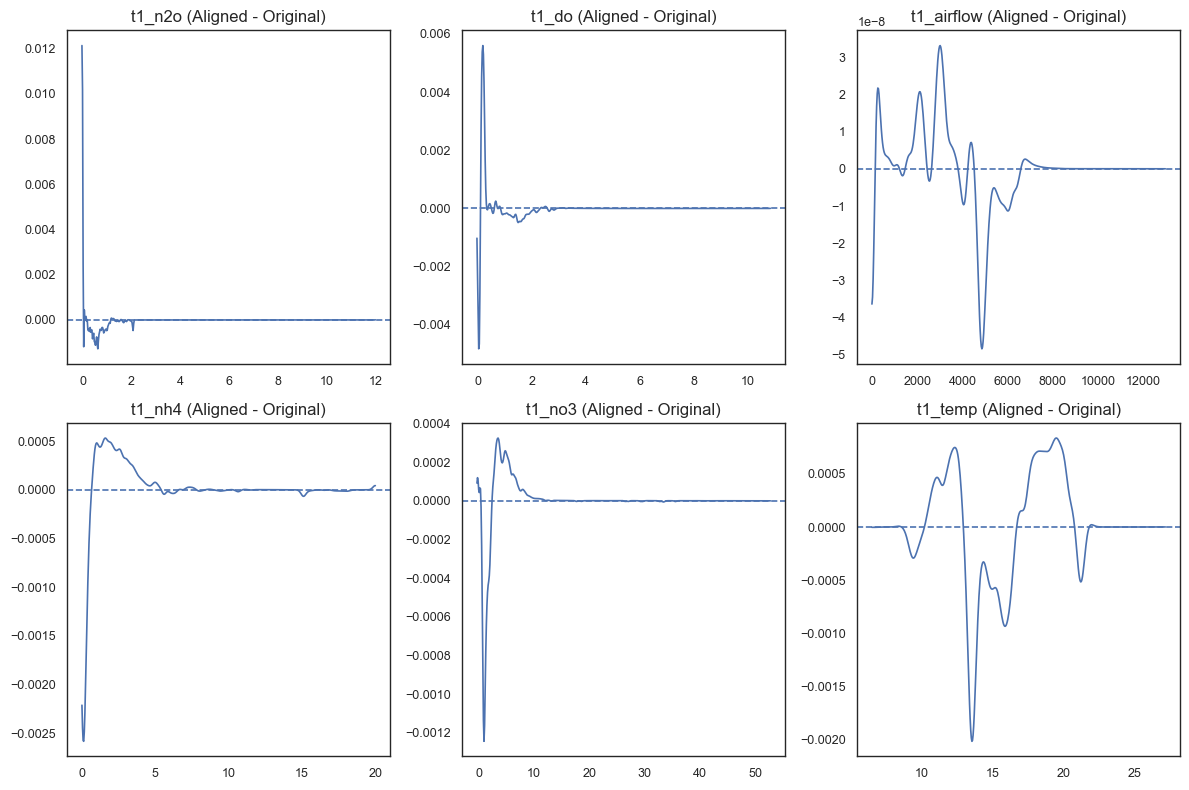

In [30]:
#Check data distribution (original vs. aligned)
plt.figure(figsize=(12,8))

#Plot KDEs for each eight key features in original and aligned dataframes
plt.figure(figsize=(12,8))

for i, col in enumerate(vars_align):
    plt.subplot(2,3,i+1)

    # Drop NaNs
    orig = df_t1[col].dropna()
    aligned = df_aligned[col].dropna()

    # Create common grid
    x = np.linspace(
        min(orig.min(), aligned.min()),
        max(orig.max(), aligned.max()),
        500
    )

    kde_orig = gaussian_kde(orig)
    kde_aligned = gaussian_kde(aligned)

    diff = kde_aligned(x) - kde_orig(x)

    plt.plot(x, diff)
    plt.axhline(0, linestyle='--')
    plt.title(f"{col} (Aligned - Original)")

plt.tight_layout()
plt.show()

Density plots mapping KDE(aligned) - KDE(original) using Gaussian KDE 
- Curves are close to zero, indicating that differences between the two distributions is very small (magnitudes of 10⁻³ to 10⁻⁸)

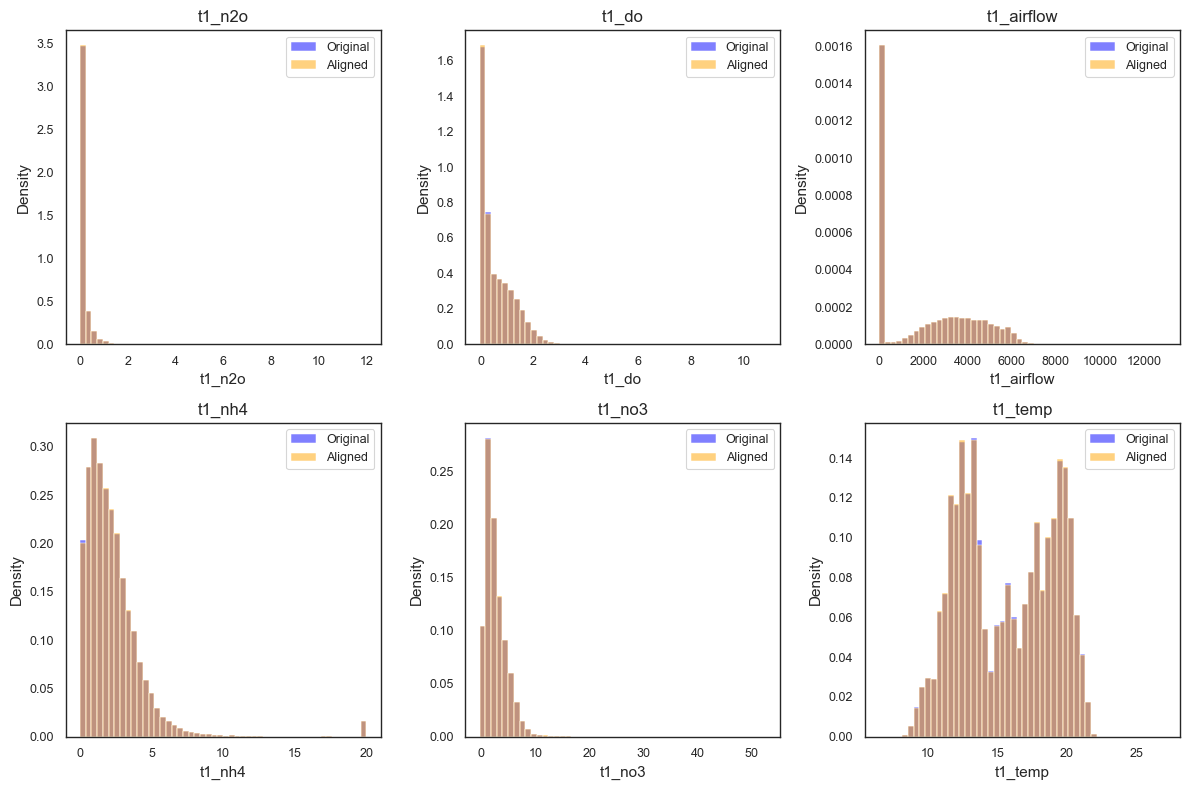

In [32]:
#Plot histograms for original and aligned dataframes to visually compare distributions
plt.figure(figsize=(12,8))

for i, col in enumerate(vars_align):
    plt.subplot(2,3,i+1)

    sns.histplot(df_t1[col], bins=50, stat="density",
                 color="blue", alpha=0.5, label="Original")

    sns.histplot(df_aligned[col], bins=50, stat="density",
                 color="orange", alpha=0.5, label="Aligned")

    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

**Notes:** 
- The original and aligned bars alsomt perfectly overlap, indicating that shifting the data did not impact the distribution of the data 
- No new peaks or visible / significant shifts in central tendency 
- No loss of extreme values (max. stays the same for both sets)

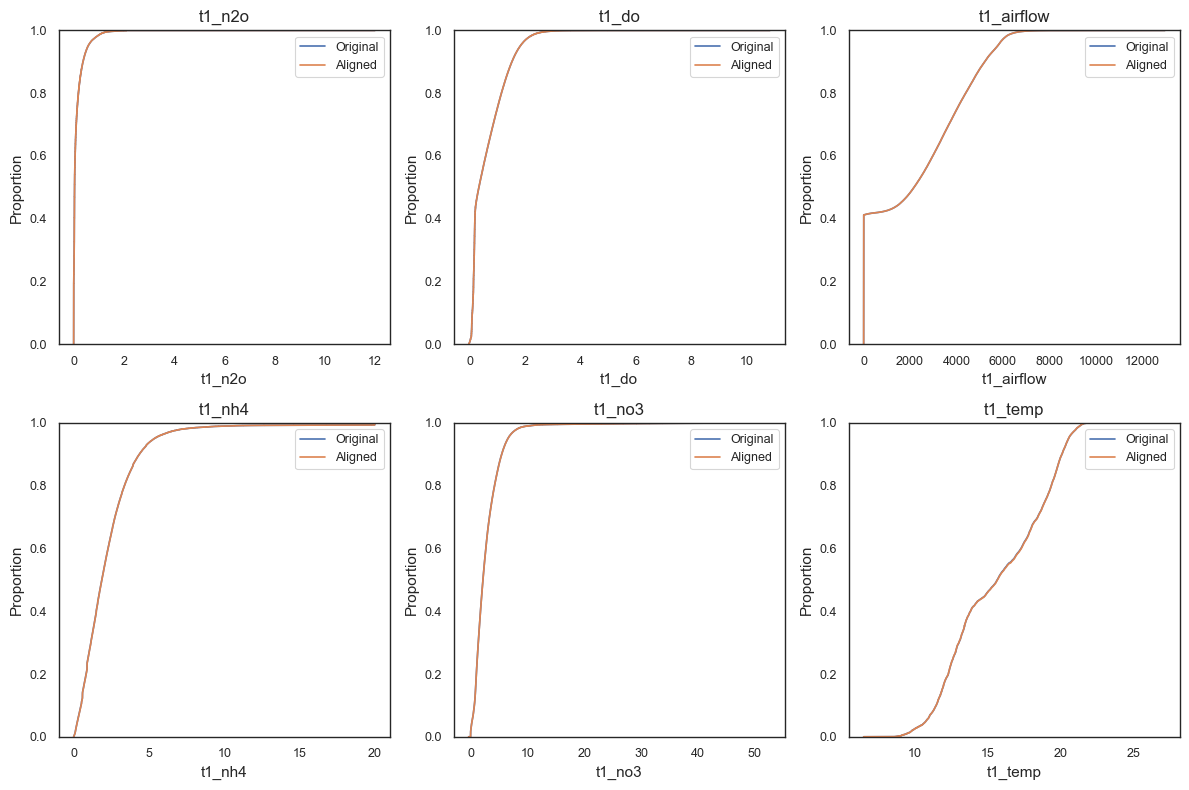

In [33]:
plt.figure(figsize=(12,8))

#Plot ECDFs for original and aligned dataframes to visually compare distributions
for i, col in enumerate(vars_align):
    plt.subplot(2,3,i+1)

    sns.ecdfplot(df_t1[col], label="Original")
    sns.ecdfplot(df_aligned[col], label="Aligned")

    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()

In [35]:
#Finally, compute KS test statistic and p-value for each feature to quantitatively compare distributions of original and aligned dataframes
for col in vars_align:
    stat, p = ks_2samp(
        df_t1[col].dropna(),
        df_aligned[col].dropna()
    )
    print(f"{col}: KS p-value = {p:.4f}")

t1_n2o: KS p-value = 1.0000
t1_do: KS p-value = 0.9971
t1_airflow: KS p-value = 1.0000
t1_nh4: KS p-value = 0.7805
t1_no3: KS p-value = 0.9235
t1_temp: KS p-value = 0.2831


All KS p-values are > 0.05, and therefore we can reject the null hypothesis that shifting the data changes the distribution of any of the variabes. 

**Notes:**
- As with with histograms and difference in KDE density curves, the ECDF curves almost perfectly overlap 
- No divergence at the tails or horizontal shift 

**Interpretation for individual variables:**

- t1_no2: rapid increase near zero, strong right-skewed distribution, few extreme values
- t1_do: moderate steepness, reflects controlled aeration system 
- t1_airflow: sharp jump at 0 (significant fraction of time airflow is ~0), mid-range S-curve (when aeration is ON?)
- t1_nh4: steep rise at low values, right-skew, most NH4 concentrations are low with some high spikes (depends on rate of ammonia removal?)
- t1_no3: steep initial rise as with NO2 and NH4 and right skew reflecting peaks in nitrate accumulation, mostly low concentrations
- t1_temp - s-curve, no significant skew, suggests distinct temperature regimes (day vs. night?, seasonal?) 


#### Appendix 2: Comparison of 10-min resampled datasets (aligned vs. non-aligned)

In [62]:
#For resampling aligned df remove extreme values in t1_n2o column before resampling to avoid skewing results
#Remove single N2O value 
max_idx = df_aligned["t1_n2o"].idxmax()
print(f"Max t1_n2o value: {df_aligned.loc[max_idx, 't1_n2o']} at timestamp {max_idx}")

Max t1_n2o value: 12.0 at timestamp 2022-11-11 08:35:00+00:00


In [65]:
extreme_count = (df_aligned["t1_n2o"] > 5).sum()
print("Number of extreme N2O values (>5):", extreme_count)

extreme_pct = (df_aligned["t1_n2o"] > 5).mean() * 100
print(f"Percentage of extreme N2O values: {extreme_pct:.4f}%")

#Remove extreme values
df_aligned.loc[df_aligned["t1_n2o"] > 5, "t1_n2o"] = np.nan
print("Remaining extreme values:", (df_aligned["t1_n2o"] > 5).sum())
print("New max value:", df_aligned["t1_n2o"].max())

Number of extreme N2O values (>5): 0
Percentage of extreme N2O values: 0.0000%
Remaining extreme values: 0
New max value: 2.1701388359069824


In [71]:
#Resample df_aligned to 10 min frequency for comparison
df_aligned_10T = resample_mixed(df_aligned, "10T")

print(f"Aligned 10 min resampled df shape: {df_aligned_10T.shape}")

Aligned 10 min resampled df shape: (105264, 34)


In [ ]:
#Save df_aligned_10T to csv 
df_aligned_10T.to_csv("../../data/df_aligned_10T.csv", index=True) 

##### Comparison of df_10T and df_aligned_10T

Comparison of resampled datasets with and without aligning timestamps before resampling to assess whether aligning timestamps has an impact on the quality / distribution of the resampled data

In [5]:
#Upload csv files 

#10-min resampled
df_10T = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_10T.csv", index_col=0, parse_dates=True)

#10-min resampled (aligned timestamps)
df_aligned_10T = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_aligned_10T.csv", index_col=0, parse_dates=True)

#Upload orginal csv file for comparison
df_t1 = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_t1_cleaned.csv", index_col=0, parse_dates=True)

In [6]:
#Check index type
print("Index type of df_10T:", type(df_10T.index))
print("Index type of df_aligned_10T:", type(df_aligned_10T.index))
print("Index type of df_t1:", type(df_t1.index))

Index type of df_10T: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index type of df_aligned_10T: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index type of df_t1: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [7]:
#Ensure chronological order of dataframes
df_10T.sort_index(inplace=True)
df_aligned_10T.sort_index(inplace=True)
df_t1.sort_index(inplace=True)

In [8]:
#Check shape of dataframes
print("Shape of df_10T:", df_10T.shape)
print("Shape of df_aligned_10T:", df_aligned_10T.shape)
print("Shape of df_t1 (original sampling frequency):", df_t1.shape)

Shape of df_10T: (105264, 34)
Shape of df_aligned_10T: (105264, 34)
Shape of df_t1 (original sampling frequency): (798466, 34)


In [9]:
#Check time range of dataframes to ensure they cover the same period
print("Time range of df_10T:", df_10T.index.min(), "to", df_10T.index.max())
print("Time range of df_aligned_10T:", df_aligned_10T.index.min(), "to", df_aligned_10T.index.max())
print("Time range of df_t1:", df_t1.index.min(), "to", df_t1.index.max())

Time range of df_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_aligned_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_t1: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00


OK - the time range of the raw dataset is Time range: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00. 

In [10]:
print("10-min resampled dataset:")
display(df_10T.head(5))
print()
print("10-min resampled (aligned) dataset:")
display(df_aligned_10T.head(5))
print()
print("Original dataset:")
display(df_t1.head(5))

10-min resampled dataset:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.124573,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.101837,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.292950,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.296754,NaN,1.481867,NaN,0.353097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.289009,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0



10-min resampled (aligned) dataset:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.103247,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.141629,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.324748,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.266913,NaN,1.481867,NaN,0.353097,NaN,2.0,2121.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.306728,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0



Original dataset:


,total_airflow,total_airflow_q,t1_valve_pct,t1_valve_pct_q,t1_n2o,t1_n2o_q,t1_nh4,t1_nh4_q,t1_no3,t1_no3_q,t1_do,t1_do_q,t1_do_sp,t1_do_sp_q,t1_phase,t1_phase_q,t1_airflow,t1_airflow_q,t1_ss,t1_ss_q,t1_temp,t1_temp_q,phasecode,phasecode_q,inlet_tank,inlet_tank_q,outlet_tank,outlet_tank_q,t1_po4,t1_po4_q,inflow,inflow_q,storm_mode,storm_mode_q
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:01:00+00:00,26829.375000,1.0,NaN,NaN,0.723958,0.0,1.670585,0.0,0.413642,0.0,0.094763,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.525374,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.238239,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:03:00+00:00,29626.341797,1.0,NaN,NaN,0.721644,0.0,1.531775,0.0,0.413642,0.0,0.115741,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.536805,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.154271,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:05:00+00:00,28605.208984,1.0,NaN,NaN,0.680556,0.0,1.440835,0.0,0.395636,0.0,0.366030,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.509847,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


In [11]:
#Check that indexes are identical for df_10T and df_aligned_10T
df_10T.index.equals(df_aligned_10T.index)

True

In [12]:
#Define function to check timestamp alignment between two dataframes and report differences
def check_timestamp_alignment(df1, df2, name1="DF1", name2="DF2"):
    
    #Extract indexes
    idx1 = df1.index
    idx2 = df2.index

    #Print number of rows in each dataframe
    print(f"{name1} rows: {len(idx1)}")
    print(f"{name2} rows: {len(idx2)}")

    #If indexes are identical, print success message and return True
    if idx1.equals(idx2):
        print("✔ Indexes are identical.")
        return True

    #If indexes are not identical, print failure message and report differences
    print("✘ Indexes are NOT identical.\n")

    #if indexes are not identical, identify timestamps only in df1 and df2
    only_in_df1 = idx1.difference(idx2)
    only_in_df2 = idx2.difference(idx1)

    #Print the number of timestamps only in each dataframe
    print(f"Timestamps only in {name1}: {len(only_in_df1)}")
    print(f"Timestamps only in {name2}: {len(only_in_df2)}")

    #print examples of timestamps only in each dataframe (up to 5 examples)
    if len(only_in_df1) > 0:
        print(f"Example from {name1} only:", only_in_df1[:5])

    if len(only_in_df2) > 0:
        print(f"Example from {name2} only:", only_in_df2[:5])

    return False

In [13]:
#Check timestamp alignment between df_10T and df_aligned_10T
check_timestamp_alignment(
    df_10T,
    df_aligned_10T,
    name1="Standard 10T",
    name2="Aligned 10T"
)

Standard 10T rows: 105264
Aligned 10T rows: 105264
✔ Indexes are identical.


True

#### Compare descriptive statistics & empirical distributions of df_10T and df_aligned_10T

In [14]:
#Define key features for comparison of the two resampled dataframes (only nummerical features considered)
cols_analysis = ['inflow', 't1_airflow', 't1_n2o', 't1_nh4','t1_no3', 't1_do', 't1_temp', 't1_po4',
             't1_ss', 't1_valve_pct']

In [15]:
#Define function to compare descriptive statistics and distributions of two dataframes for specified columns

def compare_two_datasets_table(df1, df2, cols=None, name1="DF1", name2="DF2"):

    #Detect shared numeric columns if not specified
    if cols is None:
        num1 = df1.select_dtypes(include="number").columns
        num2 = df2.select_dtypes(include="number").columns
        cols = list(set(num1).intersection(num2))

    results = []

    #Loop through each column and drop missing values
    for col in cols:
        s1 = df1[col].dropna()
        s2 = df2[col].dropna()

        #Skip columns that don't have valid values
        if len(s1) == 0 or len(s2) == 0:
            continue

        #Calculate mean and standard deviation
        mean1, mean2 = s1.mean(), s2.mean()
        std1, std2 = s1.std(), s2.std()

        #Store resulsts in a dictionary for each column and append to list
        results.append({
            "variable": col,

            f"rows_{name1}": len(df1),
            f"rows_{name2}": len(df2),

            f"mean_{name1}": mean1,
            f"mean_{name2}": mean2,
            "mean_diff": mean2 - mean1,

            f"std_{name1}": std1,
            f"std_{name2}": std2,
            "std_ratio": std2 / std1 if std1 != 0 else np.nan,

            f"median_{name1}": s1.median(),
            f"median_{name2}": s2.median(),

            f"IQR_{name1}": s1.quantile(0.75) - s1.quantile(0.25),
            f"IQR_{name2}": s2.quantile(0.75) - s2.quantile(0.25),

            f"skew_{name1}": skew(s1),
            f"skew_{name2}": skew(s2),

            f"kurtosis_{name1}": kurtosis(s1),
            f"kurtosis_{name2}": kurtosis(s2),

            f"missing_%_{name1}": df1[col].isna().mean() * 100,
            f"missing_%_{name2}": df2[col].isna().mean() * 100,

        })

    return pd.DataFrame(results).sort_values("variable")

In [19]:
#Compare df_10T with df_aligned_10T using the comparison function and display results in a table
comparison_10T = compare_two_datasets_table(
    df_10T,
    df_aligned_10T,
    cols_analysis,
    name1="10T",
    name2="10T-aligned"
)

comparison_10T

,variable,rows_10T,rows_10T-aligned,mean_10T,mean_10T-aligned,mean_diff,std_10T,std_10T-aligned,std_ratio,median_10T,median_10T-aligned,IQR_10T,IQR_10T-aligned,skew_10T,skew_10T-aligned,kurtosis_10T,kurtosis_10T-aligned,missing_%_10T,missing_%_10T-aligned
0,inflow,105264,105264,3083.477209,3083.172523,-0.304686,2187.110523,2188.031254,1.000421,2319.155070,2319.097217,2043.402734,2037.644755,1.462880,1.462291,2.230519,2.229822,13.633341,13.635241
1,t1_airflow,105264,105264,2187.268389,2187.190458,-0.077931,2020.493134,2020.201553,0.999856,2190.054934,2187.724329,3938.204852,3936.867152,0.277609,0.277741,-1.331575,-1.330921,10.163969,10.161119
5,t1_do,105264,105264,0.653175,0.653207,0.000032,0.569061,0.569319,1.000454,0.437970,0.437862,0.846336,0.846336,1.627498,1.633424,11.695298,11.750148,1.407889,1.414539
2,t1_n2o,105264,105264,0.128340,0.128367,0.000027,0.225140,0.225162,1.000096,0.037731,0.037616,0.121296,0.121412,3.479031,3.477501,16.170144,16.155377,2.664729,2.690378
3,t1_nh4,105264,105264,2.311437,2.311440,0.000003,2.200410,2.200323,0.999961,1.869051,1.870586,2.057673,2.061961,4.147375,4.148012,27.896563,27.905162,1.022192,1.024092
4,t1_no3,105264,105264,3.116311,3.116332,0.000021,2.771673,2.772084,1.000148,2.511774,2.511954,2.535694,2.538509,6.460901,6.459194,78.816717,78.787417,1.020292,1.021242
7,t1_po4,105264,105264,1.124365,1.124290,-0.000075,0.957438,0.957453,1.000016,0.891840,0.891922,0.927564,0.927804,3.295983,3.298196,20.948145,20.968501,1.069691,1.072541
8,t1_ss,105264,105264,2.552777,2.552733,-0.000044,0.852093,0.852148,1.000064,2.548741,2.548539,0.823943,0.824772,-0.223153,-0.223000,1.280149,1.278433,1.020292,1.023142
6,t1_temp,105264,105264,15.660482,15.660668,0.000186,3.381279,3.381365,1.000025,15.635127,15.635648,6.283004,6.283185,-0.001703,-0.001573,-1.335390,-1.334604,3.699270,3.701170
9,t1_valve_pct,105264,105264,44.470745,44.468659,-0.002086,40.266240,40.268408,1.000054,43.500000,43.560001,85.740001,85.779999,0.099639,0.099971,-1.677241,-1.677429,4.411765,4.419365


In [20]:
#Check time ranges of 10T resampled datasets and original dataset to ensure they cover the same period
print("Time range of df_t1:", df_t1.index.min(), "to", df_t1.index.max())
print("Time range of df_10T:", df_10T.index.min(), "to", df_10T.index.max())
print("Time range of df_aligned_10T:", df_aligned_10T.index.min(), "to", df_aligned_10T.index.max())

#Trim df_t1 to match the time range of the resampled datasets for a fair comparison
df_t1_trimmed = df_t1.loc[df_10T.index.min():df_10T.index.max()]

print("Time range of df_t1_trimmed:", df_t1_trimmed.index.min(), "to", df_t1_trimmed.index.max())

Time range of df_t1: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00
Time range of df_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_aligned_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_t1_trimmed: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:50:00+00:00


In [21]:
#Define function to compare distributiobns of two dataframes for specified columns, including effect sizes and KS test results

def compare_distributions(df_original, df_other, columns=None, trim_to_overlap=True):
    
    ''' Compare distributions of two dataframes for specified columns, including effect sizes and KS test results. 
    
    Parameters:
    df_original: The original dataframe to compare against (e.g. original sampling frequency)
    df_other: The other dataframe to compare (e.g. resampled version)
    columns: List of columns to compare. If None, will compare all shared columns.
    trim_to_overlap: If True, will trim df_original to the overlapping time range with df_other.
    '''

    if columns is None:
        columns = df_original.columns.intersection(df_other.columns)

    # If trim_to_overlap is True, trim original to overlapping time range
    if trim_to_overlap:
        start = max(df_original.index.min(), df_other.index.min())
        end = min(df_original.index.max(), df_other.index.max())
        df_original = df_original.loc[start:end]
        df_other = df_other.loc[start:end]
    
    results = []
    
    #Iterate through each column and drop missing values for comparison
    for col in columns:
        o = df_original[col].dropna()
        r = df_other[col].dropna()
        
        if len(o) == 0 or len(r) == 0:
            continue
        
        # Calculate basic descriptive statistics - mean, variance, skewness and kurtosis 
        mean_o, mean_r = o.mean(), r.mean()
        var_o, var_r = o.var(), r.var()
        skew_o, skew_r = o.skew(), r.skew()
        kurt_o, kurt_r = o.kurtosis(), r.kurtosis()
        
        # Tail behavior - identify threshold for the 95th and 99th quantiles to capture extreme events
        p95_o, p95_r = o.quantile(0.95), r.quantile(0.95)
        p99_o, p99_r = o.quantile(0.99), r.quantile(0.99)
        
        # KS test - test if the two samples come from the same distribution
        ks_stat, ks_p = ks_2samp(o, r)
        
        results.append({
            "variable": col,
            "mean_diff_%": 100 * (mean_r - mean_o) / mean_o,
            "var_ratio": var_r / var_o,
            "skew_diff": skew_r - skew_o,
            "kurt_diff": kurt_r - kurt_o,
            "p95_diff_%": 100 * (p95_r - p95_o) / p95_o,
            "p99_diff_%": 100 * (p99_r - p99_o) / p99_o,
            "KS_stat": ks_stat,
            "KS_pvalue": ks_p,
            "n_original": len(o),
            "n_other": len(r)
        })
    
    return pd.DataFrame(results).set_index("variable")

In [22]:
#Compare the original dataset with the 10-min resampled dataset

comparison_t1_10T = compare_distributions(df_t1_trimmed, df_10T, columns=cols_analysis)

print("Comparison of original dataset with 10-min resampled dataset:")
print()
print(comparison_t1_10T)

Comparison of original dataset with 10-min resampled dataset:

              mean_diff_%  var_ratio  skew_diff  kurt_diff  p95_diff_%  p99_diff_%   KS_stat      KS_pvalue  n_original  n_other
variable                                                                                                                        
inflow          -0.540517   0.882657   0.167424   0.481958   -2.631418   -1.737785  0.058940  7.239094e-243      686414    90913
t1_airflow      -0.074085   0.896608  -0.056028  -0.037178   -4.658088   -4.315680  0.069634   0.000000e+00      470169    94565
t1_n2o          -0.851573   0.981819   0.026250   0.212980   -1.002006   -0.488416  0.018879   8.305793e-27      505726   102458
t1_nh4          -0.024616   0.991722   0.032224   0.370588   -0.360775   -0.450725  0.014940   2.920596e-17      520543   104187
t1_no3           0.003624   0.995395   0.019339   0.380250   -0.215553   -0.074871  0.004369   7.256994e-02      519647   104189
t1_do           -0.262812   0.8648

In [23]:
#Compare the original dataset with the 10-min resampled aligned dataset
comparison_t1_aligned = compare_distributions(df_t1_trimmed, df_aligned_10T, columns=cols_analysis)
print("Comparison of original dataset with 10-min resampled aligned dataset:")
print()
print(comparison_t1_aligned)

Comparison of original dataset with 10-min resampled aligned dataset:

              mean_diff_%  var_ratio  skew_diff  kurt_diff  p95_diff_%  p99_diff_%   KS_stat      KS_pvalue  n_original  n_other
variable                                                                                                                        
inflow          -0.550345   0.883400   0.166835   0.481261   -2.588778   -1.689505  0.056268  2.292175e-221      686414    90911
t1_airflow      -0.077645   0.896349  -0.055896  -0.036525   -4.609512   -4.254680  0.070393   0.000000e+00      470169    94568
t1_n2o          -0.830592   0.982008   0.024719   0.198210   -0.904519   -0.464606  0.018784   1.541668e-26      505726   102431
t1_nh4          -0.024473   0.991644   0.032861   0.379188   -0.392215   -0.532401  0.014676   1.138099e-16      520543   104185
t1_no3           0.004287   0.995690   0.017632   0.350947   -0.254652   -0.074755  0.003923   1.378987e-01      519647   104188
t1_do           -0.257873 

In [24]:
#Conduct KS test comparing the original dataset with the 10-min resampled dataset for each variable

def ks_test(original, resampled):
    results = {}
    
    for col in original.columns:
        o = original[col].dropna()
        r = resampled[col].dropna()
        
        stat, p = ks_2samp(o, r)
        results[col] = {"KS_stat": stat, "p_value": p}
        
    return pd.DataFrame(results).T

print("KS test comparing original dataset with 10-min resampled dataset:")
ks_results_10T = ks_test(df_t1_trimmed[cols_analysis], df_10T[cols_analysis])
print(ks_results_10T)

KS test comparing original dataset with 10-min resampled dataset:
               KS_stat        p_value
inflow        0.058940  7.239094e-243
t1_airflow    0.069634   0.000000e+00
t1_n2o        0.018880   8.229378e-27
t1_nh4        0.014938   2.954588e-17
t1_no3        0.004361   7.343089e-02
t1_do         0.032119   9.929393e-78
t1_temp       0.001136   9.999054e-01
t1_po4        0.004075   1.120160e-01
t1_ss         0.003703   1.844121e-01
t1_valve_pct  0.069756   0.000000e+00


In [25]:
print("KS test comparing original dataset with 10-min resampled (aligned) dataset:")
ks_results_10T = ks_test(df_t1_trimmed[cols_analysis], df_aligned_10T[cols_analysis])
print(ks_results_10T)

KS test comparing original dataset with 10-min resampled (aligned) dataset:
               KS_stat        p_value
inflow        0.056268  2.292175e-221
t1_airflow    0.070393   0.000000e+00
t1_n2o        0.018786   1.528630e-26
t1_nh4        0.014673   1.150599e-16
t1_no3        0.003915   1.394416e-01
t1_do         0.032322   1.044145e-78
t1_temp       0.001119   9.999312e-01
t1_po4        0.004046   1.166414e-01
t1_ss         0.003756   1.720590e-01
t1_valve_pct  0.070315   0.000000e+00


### 2.3 - Discussion of results

The results show that the distribution for the numerical variables is preserved by the resampling, notably for the target variable N2O emissions. 

The KS statistics are nearly identical for both the df_10T and df_aligned_10T which indicates that aligning timestamps before resampling the dataset has no material impact on the empirical distribution of the data or the quality. 

**Design choice**: Since the focus of the project is to assess how mathematical and computational models can be used to predict N2O emissions for an operational WWTP with real-time data, it is important to take into account operational complexity and the need to keep the preprocessing pipeline as simple as possible to reduce computational intensitive and time required to treat the data in real-time. Therefore, we choose to not align timestamps as a part of the preprocessing pipelines as this does not have a meaningful impact on the final resampled dataset which we will use for feature engineering and modelling purposes. 